# Compare SAR runoff onset against snow pillow max-SWE timing

Mirrors `../compare_to_NorSWE/2_compare_NorSWE.ipynb`. Merge the runoff onset chips with the per-station max-SWE timings from `1_create_snow_pillow_comparison_dataset.ipynb`, compute `SAR − station` timing differences, and explore how performance depends on environmental and sampling parameters.

In [1]:
import xarray as xr
from xarray.groupers import BinGrouper
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import easysnowdata
import numpy as np
import rasterio
import os
import gc
import contextily as ctx
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch, Patch
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import rioxarray as rxr

In [2]:
MAX_SWE_TIMING_OUTPUT_ZARR_FILEPATH = Path('data/comparison_datasets/max_snow_pillow_swe_timing.zarr')
RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH = Path('data/comparison_datasets/runoff_onset_snow_pillow_station_chips.zarr')

In [3]:
runoff_onset_chips_ds = xr.open_zarr(RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH)
runoff_onset_chips_ds

<xarray.Dataset> Size: 79MB
Dimensions:              (station_id: 1210, y_rel: 25, x_rel: 25, water_year: 10)
Coordinates:
  * station_id           (station_id) <U13 63kB '1006_NV_SNTL' ... 'WC3'
    band                 (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_epsg     (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_x        (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_y        (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    time                 (station_id) datetime64[ns] 10kB dask.array<chunksize=(30,), meta=np.ndarray>
  * y_rel                (y_rel) int64 200B -960 -880 -800 -720 ... 800 880 960
  * x_rel                (x_rel) int64 200B -960 -880 -800 -720 ... 800 880 960
  * water_year           (water_year) int64 80B 2015 2016 2017 ... 2023 2024
Data variables:
    dem                  (station_id, y_rel, x_rel) float32 3MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    fcf                  (station_id, y_rel, x_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    runoff_onset         (station_id, water_year, y_rel, x_rel) float32 30MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    snow_class           (station_id, y_rel, x_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    temporal_resolution  (station_id, water_year, y_rel, x_rel) float32 30MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    worldcover           (station_id, y_rel, x_rel) float32 3MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    x_abs                (station_id, x_rel) float64 242kB dask.array<chunksize=(30, 25), meta=np.ndarray>
    y_abs                (station_id, y_rel) float64 242kB dask.array<chunksize=(30, 25), meta=np.ndarray>

In [4]:
max_swe_timing_ds = xr.open_zarr(MAX_SWE_TIMING_OUTPUT_ZARR_FILEPATH)
max_swe_timing_ds

<xarray.Dataset> Size: 871kB
Dimensions:                   (water_year: 10, station_id: 1210)
Coordinates:
  * water_year                (water_year) int64 80B 2015 2016 ... 2023 2024
  * station_id                (station_id) <U16 77kB '1000_OR_SNTL' ... 'WWC_...
    client                    (station_id) <U6 29kB dask.array<chunksize=(1210,), meta=np.ndarray>
    elevation                 (station_id) float32 5kB dask.array<chunksize=(1210,), meta=np.ndarray>
    latitude                  (station_id) float64 10kB dask.array<chunksize=(1210,), meta=np.ndarray>
    longitude                 (station_id) float64 10kB dask.array<chunksize=(1210,), meta=np.ndarray>
    network                   (station_id) <U5 24kB dask.array<chunksize=(1210,), meta=np.ndarray>
    state                     (station_id) <U2 10kB dask.array<chunksize=(1210,), meta=np.ndarray>
    station_name              (station_id) <U36 174kB dask.array<chunksize=(1210,), meta=np.ndarray>
Data variables:
    100pct_of_max_SWE_timing  (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    50pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    90pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    95pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    99pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    max_SWE_value             (water_year, station_id) float32 48kB dask.array<chunksize=(10, 1210), meta=np.ndarray>

In [5]:
runoff_onset_chips_ds['radius'] = np.sqrt(runoff_onset_chips_ds['x_rel']**2 + runoff_onset_chips_ds['y_rel']**2)
runoff_onset_chips_1000m_buffer_ds = runoff_onset_chips_ds.where(runoff_onset_chips_ds['radius'] <= 1000)
runoff_onset_chips_1000m_buffer_ds

<xarray.Dataset> Size: 91MB
Dimensions:              (station_id: 1210, y_rel: 25, x_rel: 25, water_year: 10)
Coordinates:
  * station_id           (station_id) <U13 63kB '1006_NV_SNTL' ... 'WC3'
    band                 (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_epsg     (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_x        (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_y        (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    time                 (station_id) datetime64[ns] 10kB dask.array<chunksize=(30,), meta=np.ndarray>
  * y_rel                (y_rel) int64 200B -960 -880 -800 -720 ... 800 880 960
  * x_rel                (x_rel) int64 200B -960 -880 -800 -720 ... 800 880 960
  * water_year           (water_year) int64 80B 2015 2016 2017 ... 2023 2024
Data variables:
    dem                  (station_id, y_rel, x_rel) float32 3MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    fcf                  (station_id, y_rel, x_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    runoff_onset         (station_id, water_year, y_rel, x_rel) float32 30MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    snow_class           (station_id, y_rel, x_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    temporal_resolution  (station_id, water_year, y_rel, x_rel) float32 30MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    worldcover           (station_id, y_rel, x_rel) float32 3MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    x_abs                (station_id, x_rel, y_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    y_abs                (station_id, y_rel, x_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    radius               (x_rel, y_rel) float64 5kB nan nan nan ... nan nan nan

In [6]:
snow_pillow_chips_and_max_swe_timing_ds = xr.merge([runoff_onset_chips_1000m_buffer_ds, max_swe_timing_ds], join='inner')
snow_pillow_chips_and_max_swe_timing_ds

<xarray.Dataset> Size: 92MB
Dimensions:                   (station_id: 1210, water_year: 10, x_rel: 25,
                               y_rel: 25)
Coordinates: (12/16)
  * station_id                (station_id) <U16 77kB '1006_NV_SNTL' ... 'WC3'
    band                      (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_epsg          (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_x             (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_y             (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    time                      (station_id) datetime64[ns] 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    ...                        ...
    network                   (station_id) <U5 24kB dask.array<chunksize=(1210,), meta=np.ndarray>
    state                     (station_id) <U2 10kB dask.array<chunksize=(1210,), meta=np.ndarray>
    station_name              (station_id) <U36 174kB dask.array<chunksize=(1210,), meta=np.ndarray>
  * water_year                (water_year) int64 80B 2015 2016 ... 2023 2024
  * x_rel                     (x_rel) int64 200B -960 -880 -800 ... 800 880 960
  * y_rel                     (y_rel) int64 200B -960 -880 -800 ... 800 880 960
Data variables: (12/15)
    dem                       (station_id, y_rel, x_rel) float32 3MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    fcf                       (station_id, y_rel, x_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    runoff_onset              (station_id, water_year, y_rel, x_rel) float32 30MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    snow_class                (station_id, y_rel, x_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    temporal_resolution       (station_id, water_year, y_rel, x_rel) float32 30MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    worldcover                (station_id, y_rel, x_rel) float32 3MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    ...                        ...
    100pct_of_max_SWE_timing  (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    50pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    90pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    95pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    99pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    max_SWE_value             (water_year, station_id) float32 48kB dask.array<chunksize=(10, 1210), meta=np.ndarray>

In [7]:
for pct in [100, 99, 95, 90, 50]:
    snow_pillow_chips_and_max_swe_timing_ds[f'sar_minus_station_{pct}pct_timing'] = (
        snow_pillow_chips_and_max_swe_timing_ds['runoff_onset']
        - snow_pillow_chips_and_max_swe_timing_ds[f'{pct}pct_of_max_SWE_timing']
    )
snow_pillow_chips_and_max_swe_timing_ds

<xarray.Dataset> Size: 394MB
Dimensions:                          (station_id: 1210, water_year: 10,
                                      x_rel: 25, y_rel: 25)
Coordinates: (12/16)
  * station_id                       (station_id) <U16 77kB '1006_NV_SNTL' .....
    band                             (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_epsg                 (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_x                    (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_y                    (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    time                             (station_id) datetime64[ns] 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    ...                               ...
    network                          (station_id) <U5 24kB dask.array<chunksize=(1210,), meta=np.ndarray>
    state                            (station_id) <U2 10kB dask.array<chunksize=(1210,), meta=np.ndarray>
    station_name                     (station_id) <U36 174kB dask.array<chunksize=(1210,), meta=np.ndarray>
  * water_year                       (water_year) int64 80B 2015 2016 ... 2024
  * x_rel                            (x_rel) int64 200B -960 -880 ... 880 960
  * y_rel                            (y_rel) int64 200B -960 -880 ... 880 960
Data variables: (12/20)
    dem                              (station_id, y_rel, x_rel) float32 3MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    fcf                              (station_id, y_rel, x_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    runoff_onset                     (station_id, water_year, y_rel, x_rel) float32 30MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    snow_class                       (station_id, y_rel, x_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    temporal_resolution              (station_id, water_year, y_rel, x_rel) float32 30MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    worldcover                       (station_id, y_rel, x_rel) float32 3MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    ...                               ...
    max_SWE_value                    (water_year, station_id) float32 48kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    sar_minus_station_100pct_timing  (station_id, water_year, y_rel, x_rel) float64 60MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    sar_minus_station_99pct_timing   (station_id, water_year, y_rel, x_rel) float64 60MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    sar_minus_station_95pct_timing   (station_id, water_year, y_rel, x_rel) float64 60MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    sar_minus_station_90pct_timing   (station_id, water_year, y_rel, x_rel) float64 60MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    sar_minus_station_50pct_timing   (station_id, water_year, y_rel, x_rel) float64 60MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>

## Multi-parameter performance exploration

We want to know how performance depends on **`fcf`, `temporal_resolution`, `max_SWE_value`, `radius`, `worldcover`, `snow_class`, `network`**, and which *combinations* of parameters give the best agreement between SAR runoff onset and station max-SWE timing.

The workflow:

1. **Build one tidy pixel-level DataFrame** (`master_df`) with the error + every predictor.
2. **1D conditional sweeps** — median bias, MAD, % within ±7 d, and counts per predictor bin.
3. **2D binned heatmaps** for any predictor pair.
4. **Shallow decision tree** on |error| → human-readable threshold rules ("best regime" candidates).
5. *(optional)* **Gradient-boosted model** → permutation importance + partial dependence.
6. **Robustness check** at station-year level (pixels within a chip are not independent!).

Pick the error variable to focus on with `FOCUS` below (all five `sar_minus_*` columns are kept in the table, so switching is cheap).

In [8]:
# --- 1. build the master pixel-level DataFrame -------------------------------
sar_vars = [v for v in snow_pillow_chips_and_max_swe_timing_ds.data_vars if v.startswith("sar_minus")]

ds_exp = snow_pillow_chips_and_max_swe_timing_ds

# network is a per-station *string* coordinate; broadcasting strings to 4D is
# memory-hungry, so encode as integer categories first and keep a lookup table.
network_cat = pd.Categorical(ds_exp['network'].values)
NETWORK_NAMES = dict(enumerate(network_cat.categories))
ds_exp = ds_exp.assign_coords(network_code=('station_id', network_cat.codes)).reset_coords(['network_code'])

keep = sar_vars + ["fcf", "temporal_resolution", "max_SWE_value", "radius",
                   "worldcover", "snow_class", "network_code","latitude", "longitude"]
explore = ds_exp[keep].load()

tmpl = explore[sar_vars[0]]            # (station_id, water_year, y_rel, x_rel)

def flat(name, dtype=None):
    """Broadcast a variable to the 4D template and flatten to 1D (C order)."""
    a = explore[name].broadcast_like(tmpl).transpose(*tmpl.dims).values.ravel()
    return a.astype(dtype) if dtype is not None else a

master_df = pd.DataFrame({
    "fcf":      flat("fcf", "float32"),
    "temp_res": flat("temporal_resolution", "float32"),
    "max_swe":  flat("max_SWE_value", "float32"),
    "radius":   flat("radius", "float32"),
    "worldcover":  pd.Categorical(flat("worldcover")),
    "snow_class":  pd.Categorical(flat("snow_class")),
    "network":     pd.Categorical(flat("network_code")),
    "latitude":   flat("latitude", "float32"),
    "longitude":   flat("longitude", "float32"),
})
for v in sar_vars:
    master_df[v] = flat(v, "float32")

# integer station / year ids (NOT the string station ids -- those would be GBs)
n_st, n_wy = tmpl.sizes["station_id"], tmpl.sizes["water_year"]
n_pix = tmpl.sizes["y_rel"] * tmpl.sizes["x_rel"]
master_df["station_idx"] = np.repeat(np.arange(n_st, dtype="int32"), n_wy * n_pix)
master_df["water_year"]  = np.tile(np.repeat(explore.water_year.values.astype("int16"), n_pix), n_st)

# drop pixels with no error data at all (outside 1 km buffer, missing years, water, ...)
master_df = master_df.dropna(subset=sar_vars, how="all").reset_index(drop=True)

del explore
gc.collect()

print(f"{len(master_df):,} pixel samples, {master_df.memory_usage(deep=True).sum()/1e9:.2f} GB")
master_df.head()

4,196,221 pixel samples, 0.22 GB


,fcf,temp_res,max_swe,radius,worldcover,snow_class,network,latitude,longitude,sar_minus_station_100pct_timing,sar_minus_station_99pct_timing,sar_minus_station_95pct_timing,sar_minus_station_90pct_timing,sar_minus_station_50pct_timing,station_idx,water_year
0,2.0,7.8,381.0,989.545349,30.0,5.0,4,40.357201,-116.8647,24.0,24.0,21.0,18.0,-19.0,0,2017
1,6.0,8.0,381.0,973.242004,30.0,5.0,4,40.357201,-116.8647,6.0,6.0,3.0,0.0,-37.0,0,2017
2,10.0,7.1,381.0,963.327576,30.0,6.0,4,40.357201,-116.8647,6.0,6.0,3.0,0.0,-37.0,0,2017
3,11.0,7.2,381.0,960.000000,20.0,6.0,4,40.357201,-116.8647,36.0,36.0,33.0,30.0,-7.0,0,2017
4,11.0,7.3,381.0,963.327576,20.0,6.0,4,40.357201,-116.8647,66.0,66.0,63.0,60.0,23.0,0,2017


In [9]:
# --- choose which error variable to analyze ----------------------------------
FOCUS = "sar_minus_station_95pct_timing"     # <-- switch here to re-run everything below

master_df["err"] = master_df[FOCUS]
master_df["abs_err"] = master_df["err"].abs()

# readable labels for ESA WorldCover classes
WC_NAMES = {10: "tree", 20: "shrub", 30: "grass", 40: "crop", 50: "built",
            60: "bare", 70: "snow/ice", 80: "water", 90: "wetland",
            95: "mangrove", 100: "moss/lichen"}

SNOW_CLASS_NAMES = {1: "Tundra", 2: "Boreal Forest", 3: "Maritime", 4: "Ephemeral",
                    5: "Prairie", 6: "Montane Forest", 7: "Ice", 8: "Ocean", 9: "Fill"}

print(f"NETWORK_NAMES: {NETWORK_NAMES}")

NETWORK_NAMES: {0: 'BCSS', 1: 'CCSS', 2: 'MSNT', 3: 'NVE', 4: 'SNTL'}


In [10]:
# --- 2. 1D conditional sweeps -------------------------------------------------
def perf_stats(s):
    """Performance summary of an error sample: bias, robust spread, hit rate, n."""
    s = s.dropna()
    med = s.median()
    return pd.Series({
        "bias_median": med,
        "mad": (s - med).abs().median(),
        "pct_within_7d": (s.abs() <= 7).mean() * 100,
        "pct_within_10d": (s.abs() <= 10).mean() * 100,
        "pct_within_14d": (s.abs() <= 14).mean() * 100,
        "n": s.size,
    })

binnings = {
    "fcf":      np.arange(0, 101, 10),
    "temp_res": np.arange(0, 31, 3),
    "max_swe":  np.arange(0, 1600, 100),   # mm
    "radius":   np.arange(0, 1001, 100),
}
categoricals = ["worldcover", "snow_class", "network"]

sweeps = {}
for col, bins in binnings.items():
    sweeps[col] = (master_df.groupby(pd.cut(master_df[col], bins), observed=False)["err"]
                            .apply(perf_stats).unstack())
for col in categoricals:
    sweeps[col] = master_df.groupby(col, observed=True)["err"].apply(perf_stats).unstack()

sweeps["worldcover"].rename(index=WC_NAMES)

,bias_median,mad,pct_within_7d,pct_within_10d,pct_within_14d,n
worldcover,,,,,,
tree,-8.0,17.0,25.312405,34.662273,44.854405,3073979.0
shrub,-1.0,12.0,33.843676,43.764882,58.249267,86935.0
grass,0.0,12.0,33.108446,44.253418,56.358007,778019.0
crop,1.5,10.5,33.678756,52.849741,62.176166,386.0
built,-2.0,16.0,26.870268,36.969075,46.888233,7793.0
bare,3.0,12.0,31.603179,42.525952,53.708248,92092.0
snow/ice,7.0,11.0,31.271734,42.548435,59.612519,4026.0
water,13.0,21.0,19.211140,26.538970,33.333333,47613.0
wetland,-2.0,17.0,33.658537,38.146341,45.658537,1025.0


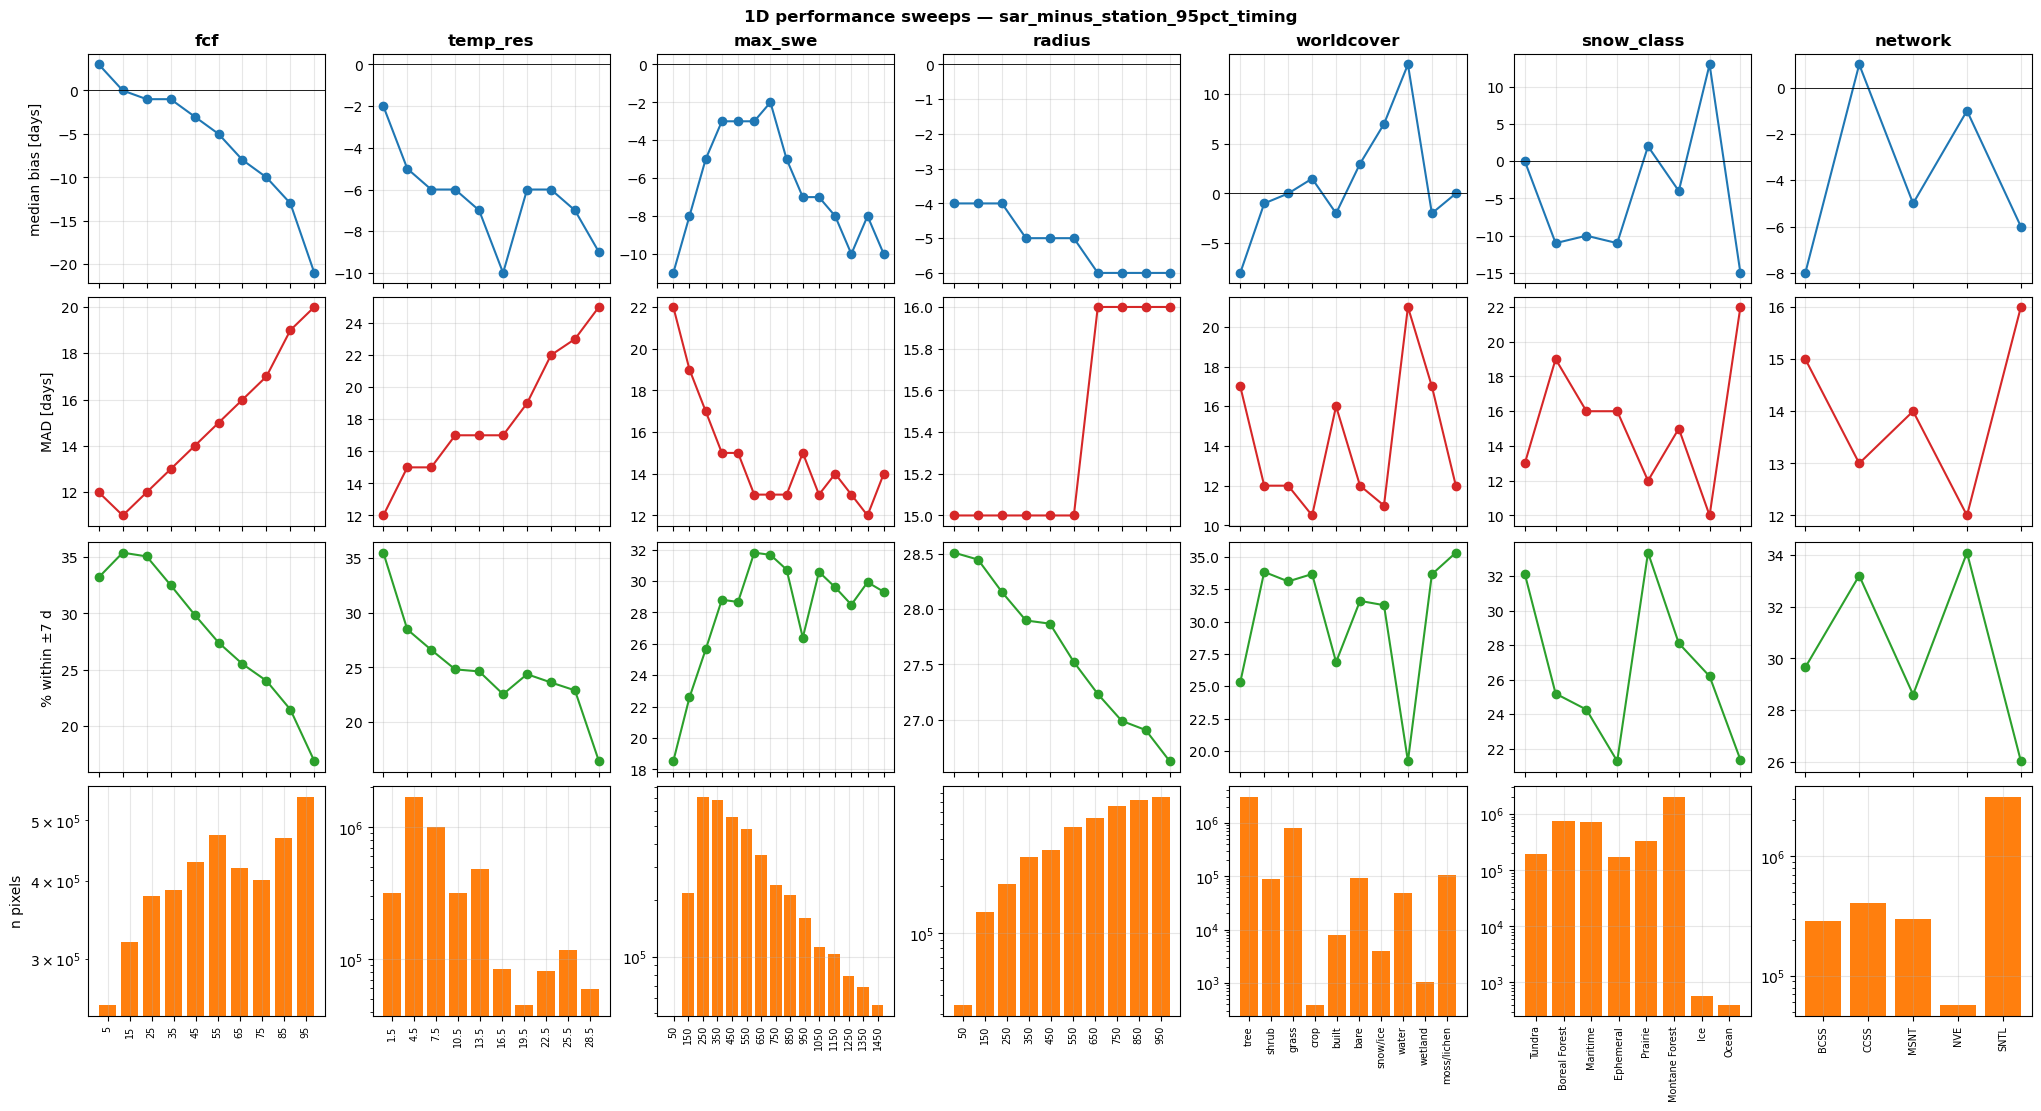

In [11]:
# --- plot the sweeps: one column per predictor, rows = bias / MAD / hit rate / n
npred = len(sweeps)
f, axs = plt.subplots(4, npred, figsize=(2.9 * npred, 11), layout="constrained")

for j, (name, tbl) in enumerate(sweeps.items()):
    x = np.arange(len(tbl))
    if isinstance(tbl.index[0], pd.Interval):
        labels = [f"{iv.mid:g}" for iv in tbl.index]
    elif name == "worldcover":
        labels = [WC_NAMES.get(int(c), str(c)) for c in tbl.index]
    elif name == "snow_class":
        labels = [SNOW_CLASS_NAMES.get(int(c), str(c)) for c in tbl.index]
    elif name == "network":
        labels = [NETWORK_NAMES.get(int(c), str(c)) for c in tbl.index]
    else:
        labels = [str(c) for c in tbl.index]

    axs[0, j].plot(x, tbl["bias_median"], "o-")
    axs[0, j].axhline(0, color="k", lw=0.6)
    axs[1, j].plot(x, tbl["mad"], "o-", color="tab:red")
    axs[2, j].plot(x, tbl["pct_within_7d"], "o-", color="tab:green")
    axs[3, j].bar(x, tbl["n"], color="tab:orange")
    axs[3, j].set_yscale("log")

    axs[0, j].set_title(name, fontweight="bold")
    for i in range(4):
        axs[i, j].set_xticks(x)
        axs[i, j].set_xticklabels(labels if i == 3 else [], rotation=90, fontsize=7)
        axs[i, j].grid(alpha=0.3)

axs[0, 0].set_ylabel("median bias [days]")
axs[1, 0].set_ylabel("MAD [days]")
axs[2, 0].set_ylabel("% within ±7 d")
axs[3, 0].set_ylabel("n pixels")
f.suptitle(f"1D performance sweeps — {FOCUS}", fontweight="bold");

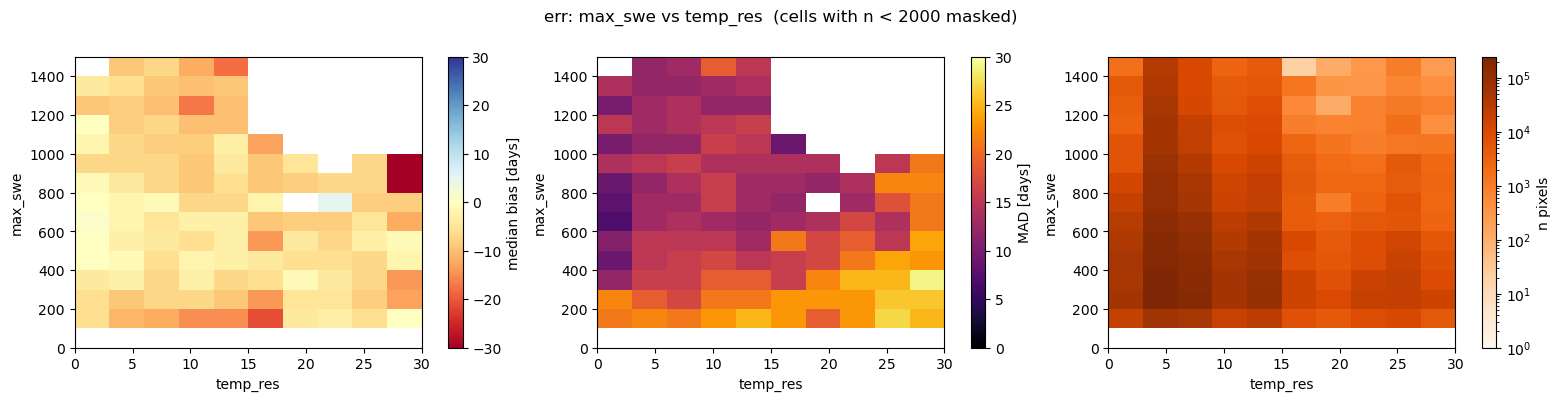

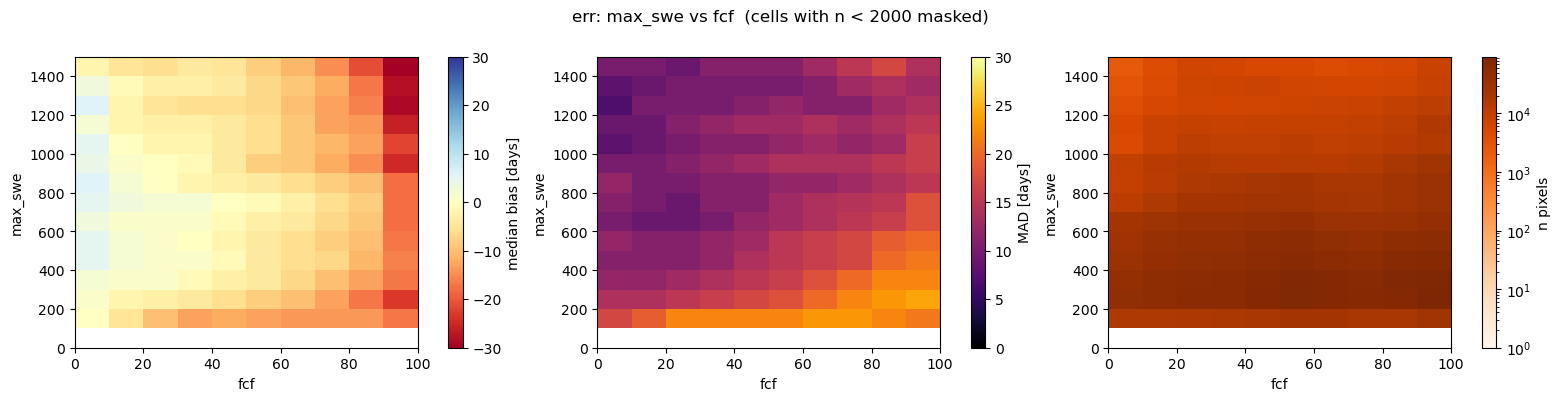

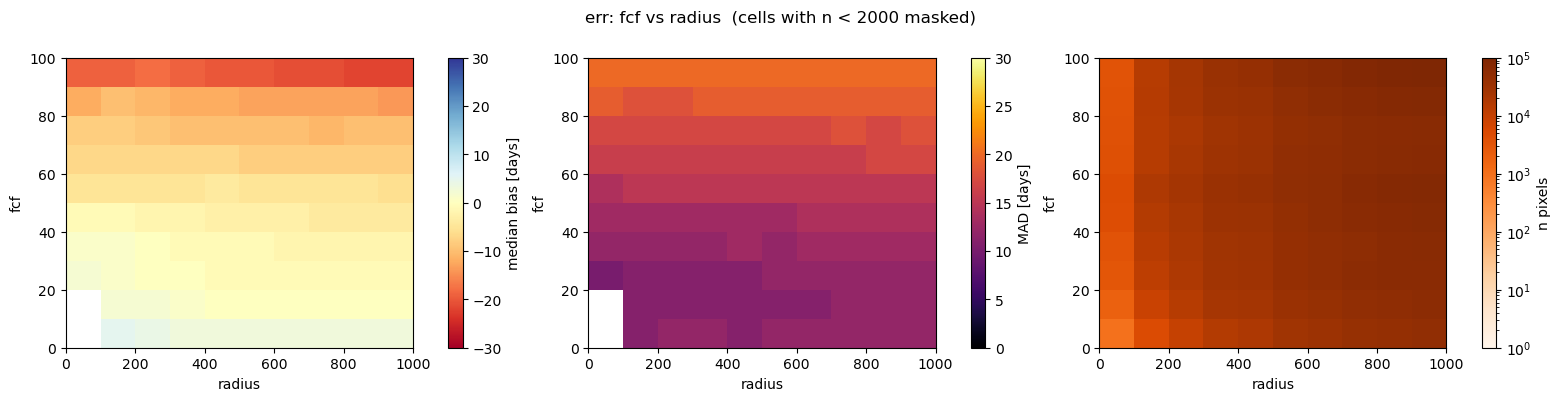

In [12]:
# --- 3. generic 2D binned heatmap (median bias / MAD / count) -----------------
def binned_2d(df, xcol, ycol, xbins, ybins, val="err", min_n=2000,
              bias_lim=30, mad_lim=30, subtitle=None):
    """Binned heatmaps (median bias / MAD / count) for ANY pair of continuous predictors."""
    gx, gy = pd.cut(df[xcol], xbins), pd.cut(df[ycol], ybins)
    gb = df.groupby([gy, gx], observed=False)[val]
    med = gb.median().unstack()
    mad = gb.agg(lambda s: (s - s.median()).abs().median()).unstack()
    n   = gb.size().unstack().astype(float)
    med, mad = med.where(n >= min_n), mad.where(n >= min_n)   # hide sparse cells

    f, axs = plt.subplots(1, 3, figsize=(15.5, 3.9), layout="constrained")
    pm0 = axs[0].pcolormesh(xbins, ybins, med.values, cmap="RdYlBu",
                            vmin=-bias_lim, vmax=bias_lim)
    pm1 = axs[1].pcolormesh(xbins, ybins, mad.values, cmap="inferno",
                            vmin=0, vmax=mad_lim)
    pm2 = axs[2].pcolormesh(xbins, ybins, n.where(n > 0).values, cmap="Oranges",
                            norm=LogNorm(vmin=1, vmax=max(n.values.max(), 10)))
    for ax, pm, lab in zip(axs, [pm0, pm1, pm2],
                           ["median bias [days]", "MAD [days]", "n pixels"]):
        f.colorbar(pm, ax=ax, label=lab)
        ax.set_xlabel(xcol); ax.set_ylabel(ycol)
    f.suptitle(f"{val}: {ycol} vs {xcol}  (cells with n < {min_n} masked)\n{subtitle or ''}")
    return med, mad, n

_ = binned_2d(master_df, "temp_res", "max_swe",
              np.arange(0, 31, 3), np.arange(0, 1600, 100))
_ = binned_2d(master_df, "fcf", "max_swe",
              np.arange(0, 101, 10), np.arange(0, 1600, 100))
_ = binned_2d(master_df, "radius", "fcf",
              np.arange(0, 1001, 100), np.arange(0, 101, 10))

worldcover 10 (tree): 3,073,979 px
worldcover 30 (grass): 778,019 px
worldcover 100 (moss/lichen): 104,353 px
worldcover 60 (bare): 92,092 px
worldcover 20 (shrub): 86,935 px
worldcover 80 (water): 47,613 px


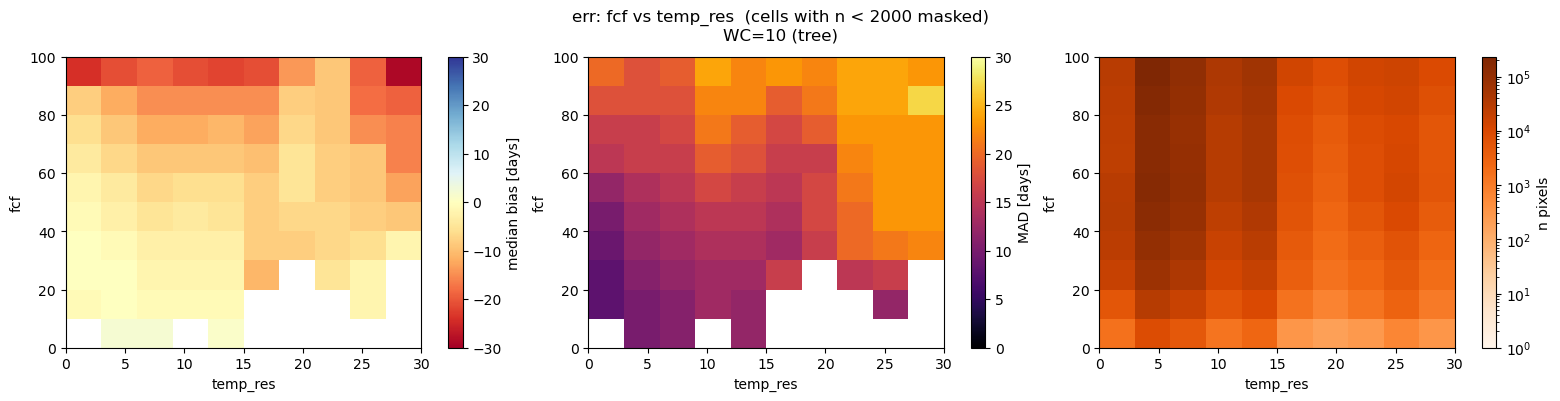

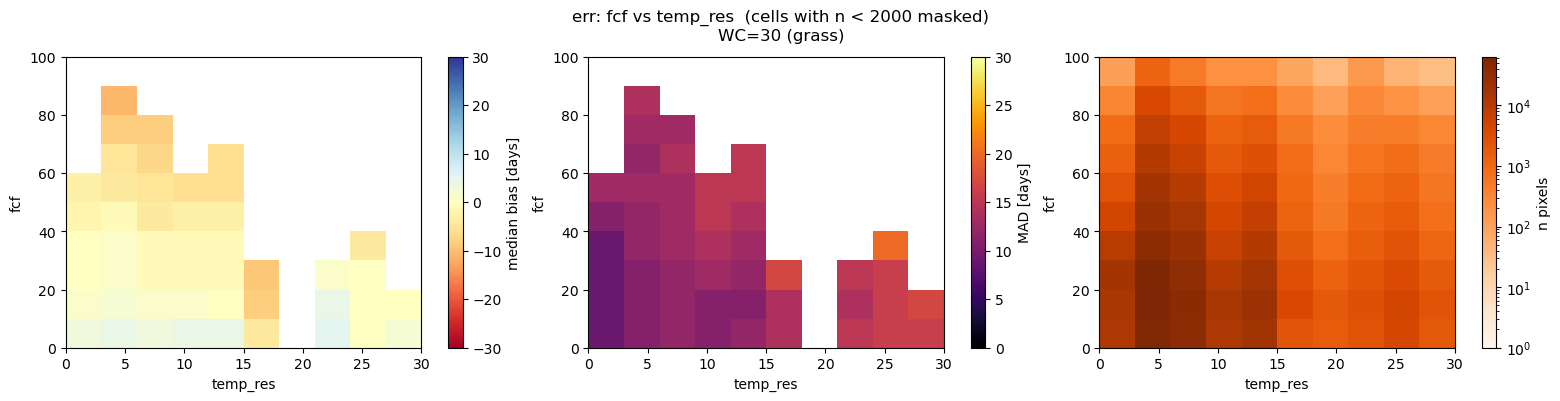

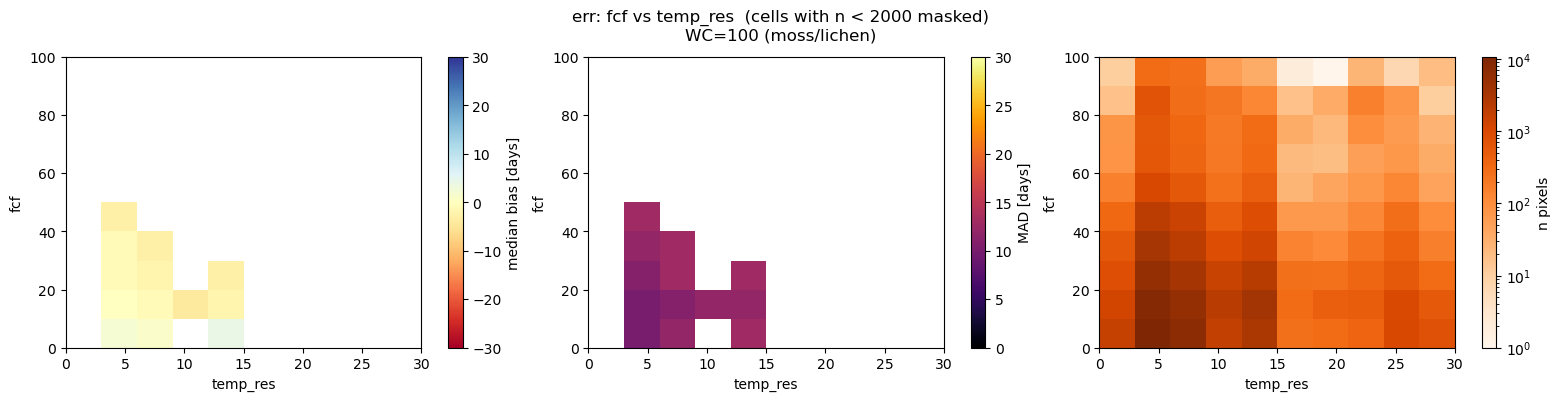

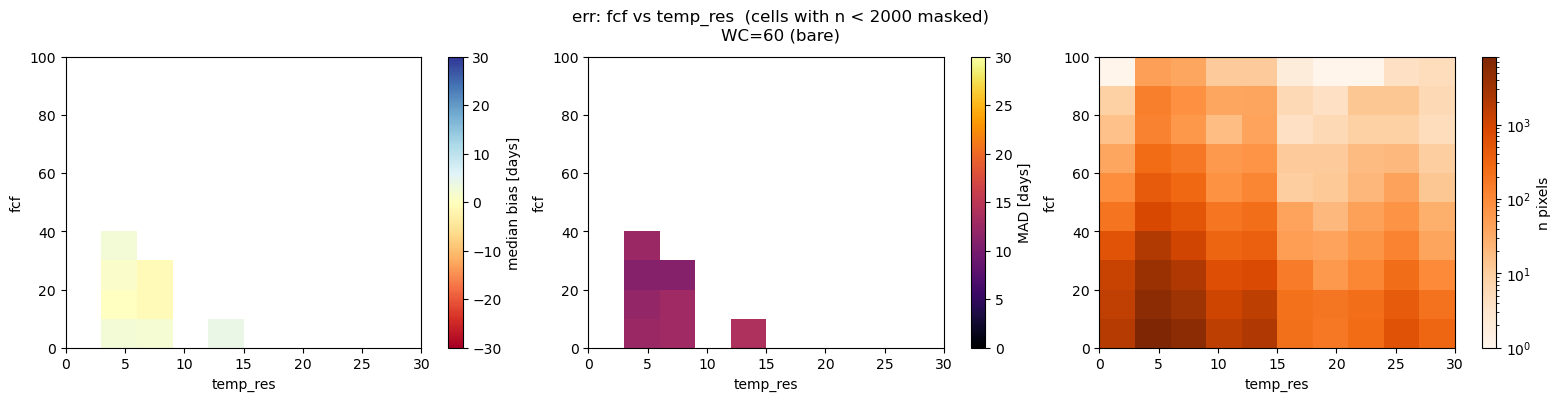

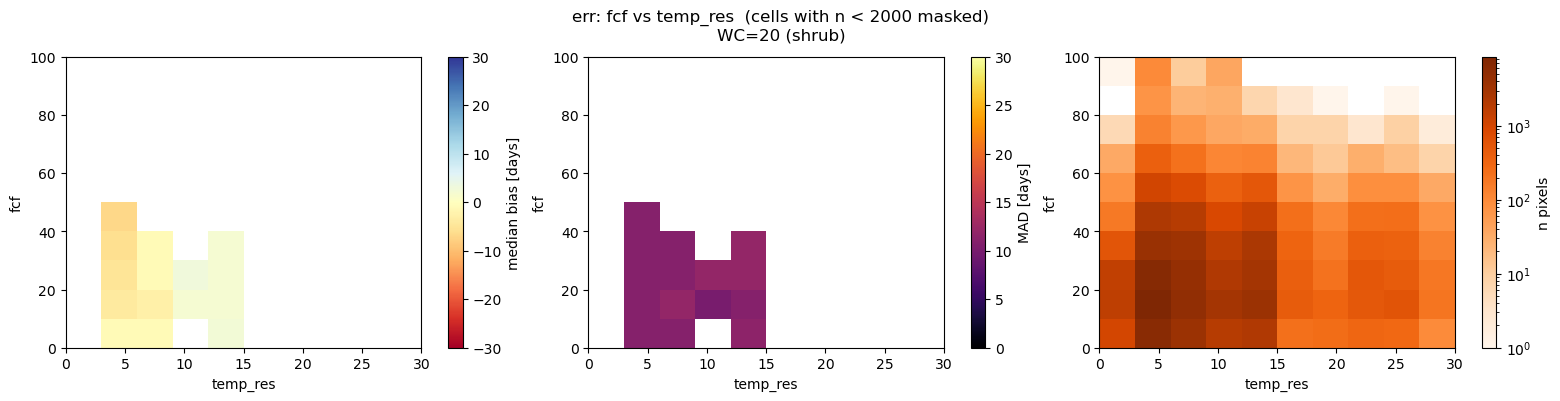

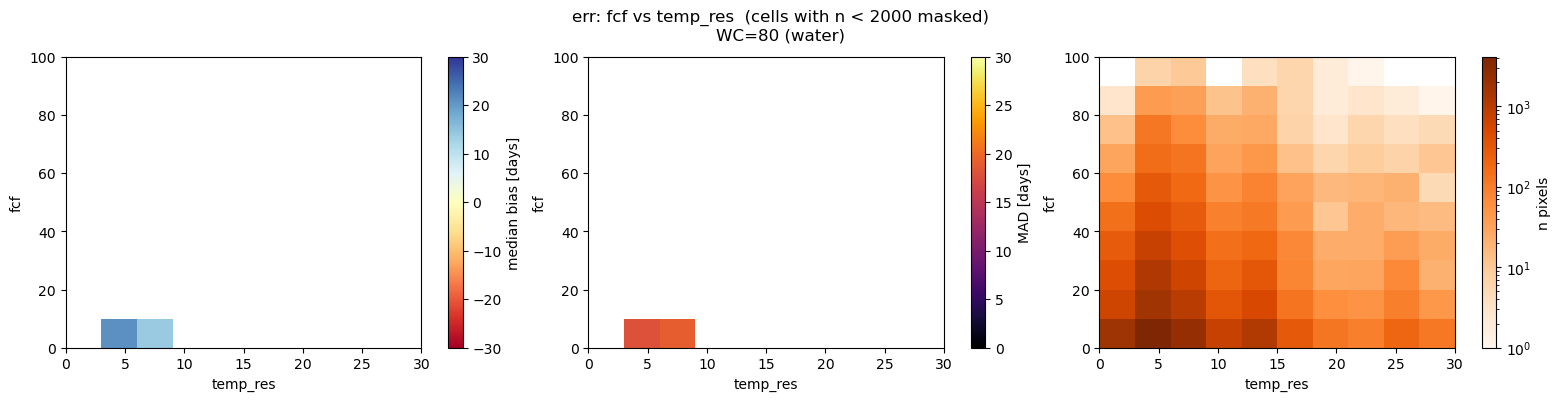

In [13]:
# --- categorical conditioning: same fcf x temp-res map, faceted by worldcover -
top_wc = master_df["worldcover"].value_counts().head(6).index
for wc in top_wc:
    sub_wc = master_df[master_df["worldcover"] == wc]
    print(f"worldcover {int(wc)} ({WC_NAMES.get(int(wc), '?')}): "
          f"{len(sub_wc):,} px")
    _ = binned_2d(sub_wc, "temp_res", "fcf",
                  np.arange(0, 31, 3), np.arange(0, 101, 10), subtitle=f"WC={int(wc)} ({WC_NAMES.get(int(wc), '?')})")

snow_class 1 (Tundra): 194,342 px
snow_class 2 (Boreal Forest): 745,762 px
snow_class 3 (Maritime): 710,441 px
snow_class 4 (Ephemeral): 172,623 px
snow_class 5 (Prairie): 331,624 px
snow_class 6 (Montane Forest): 2,040,475 px


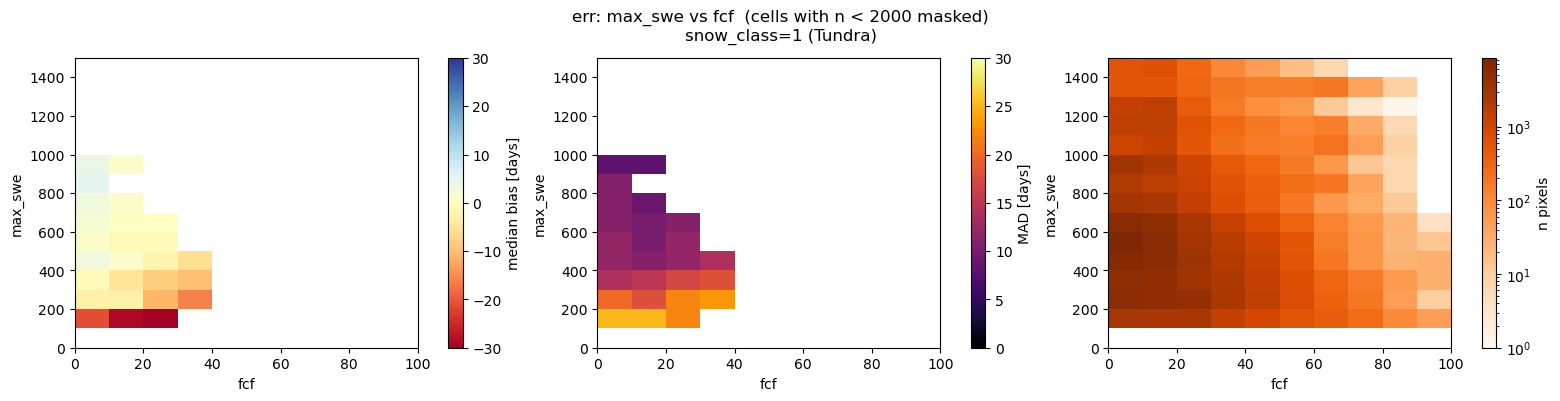

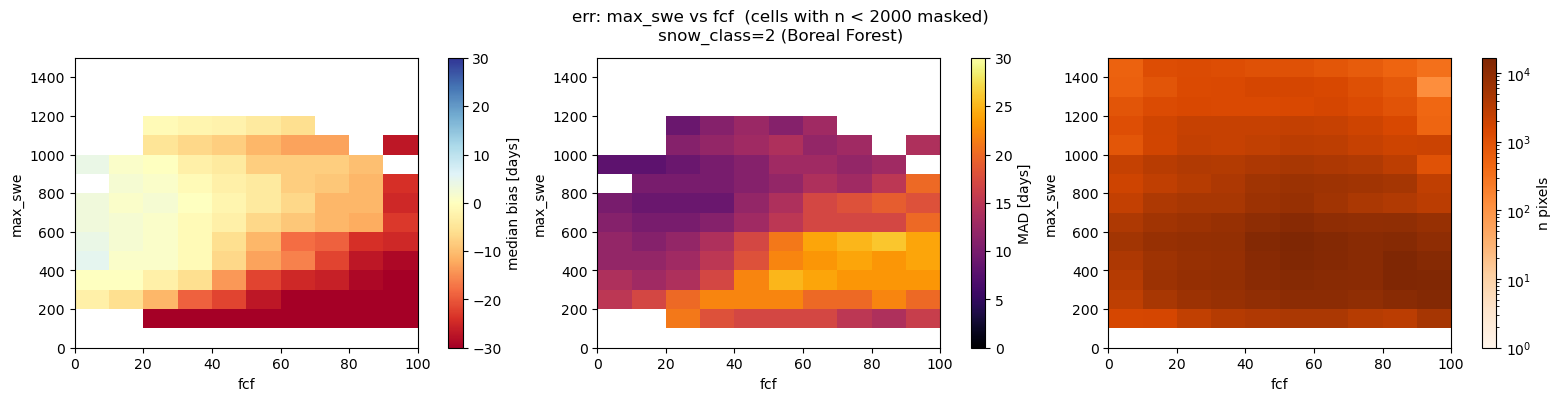

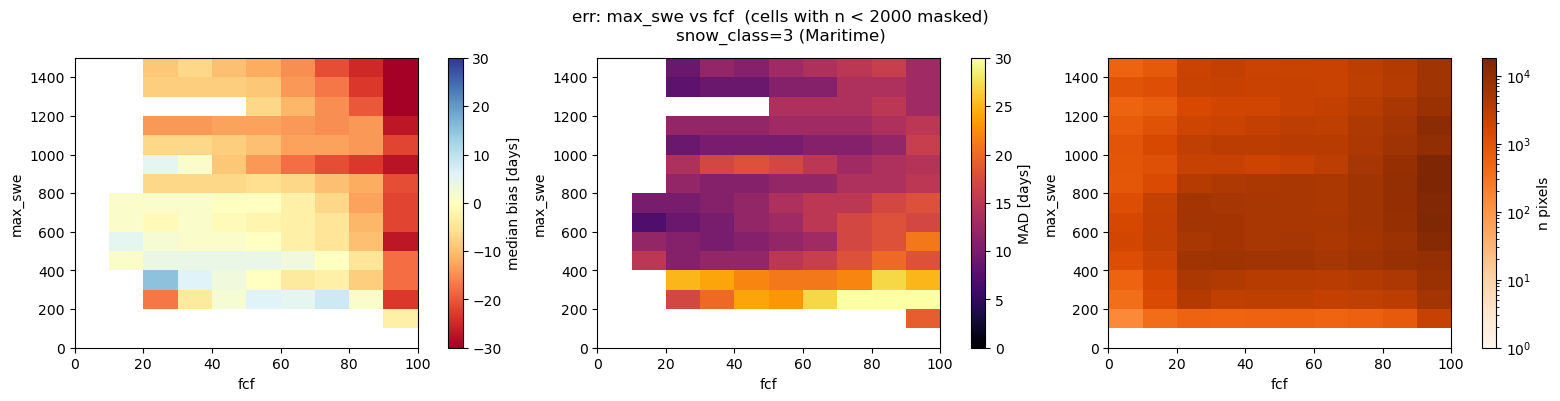

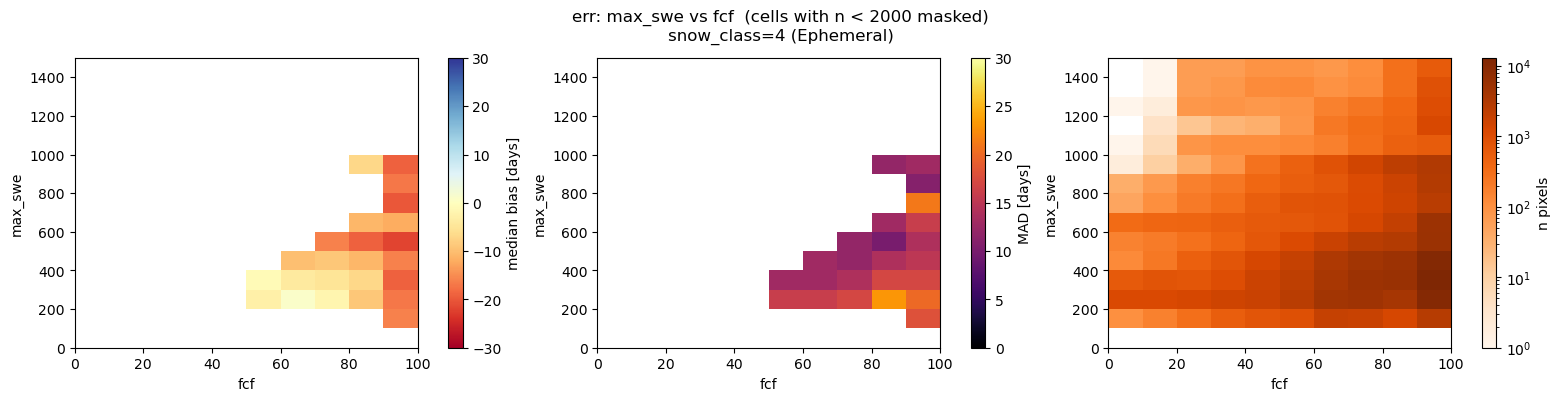

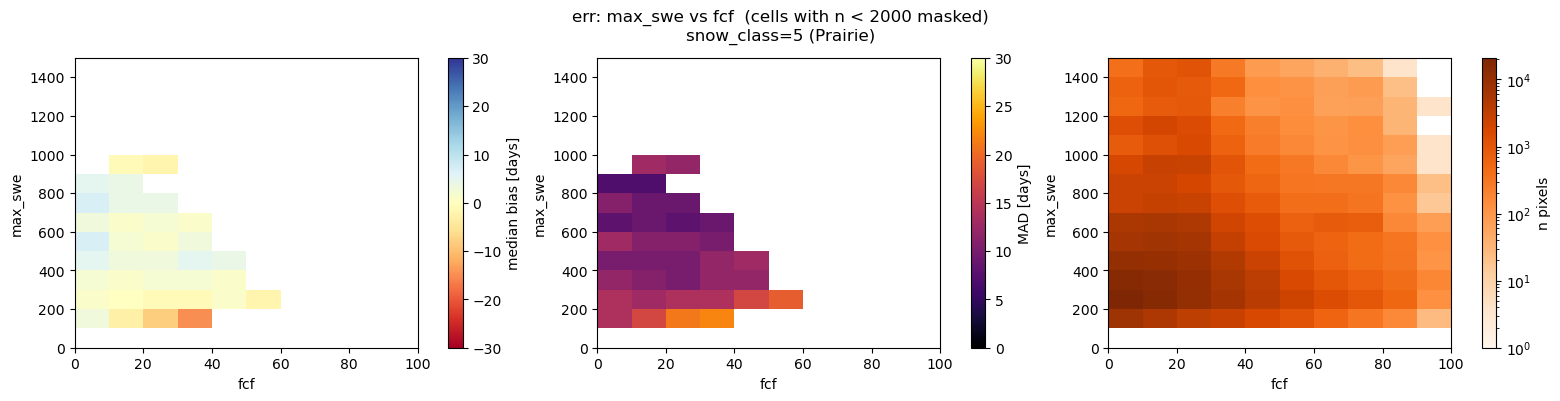

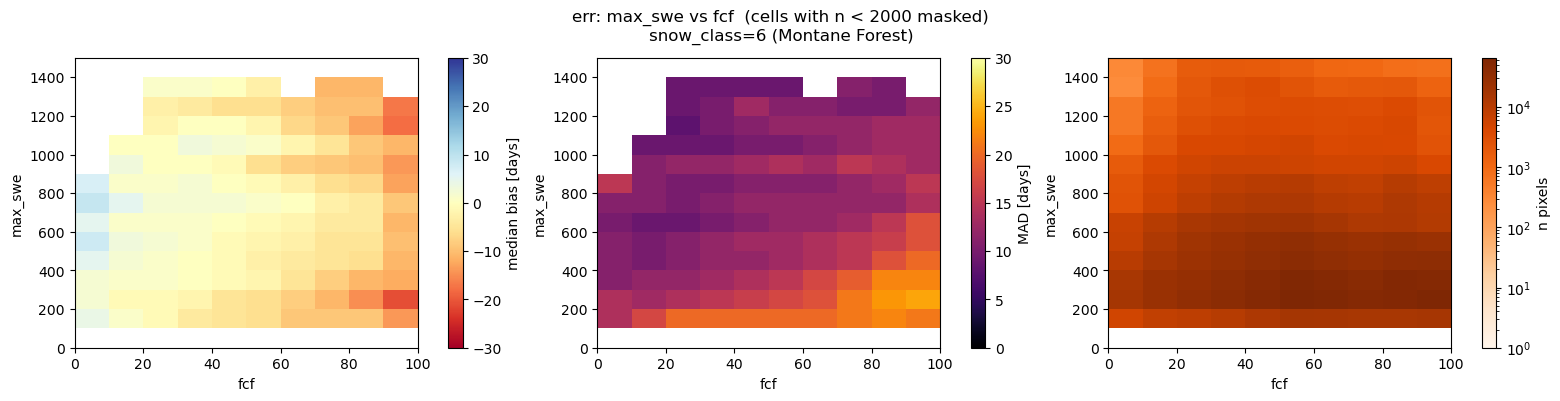

In [14]:
# --- categorical conditioning: fcf x max_swe map, faceted by snow class -------
for sc_code, sc_name in SNOW_CLASS_NAMES.items():
    sub_sc = master_df[master_df["snow_class"] == sc_code]
    if len(sub_sc) < 2000:
        continue
    print(f"snow_class {sc_code} ({sc_name}): {len(sub_sc):,} px")
    _ = binned_2d(sub_sc, "fcf", "max_swe",
                  np.arange(0, 101, 10), np.arange(0, 1600, 100), subtitle=f"snow_class={sc_code} ({sc_name})")

network BCSS: 286,776 px
network CCSS: 410,061 px
network MSNT: 297,302 px
network NVE: 57,057 px
network SNTL: 3,145,025 px


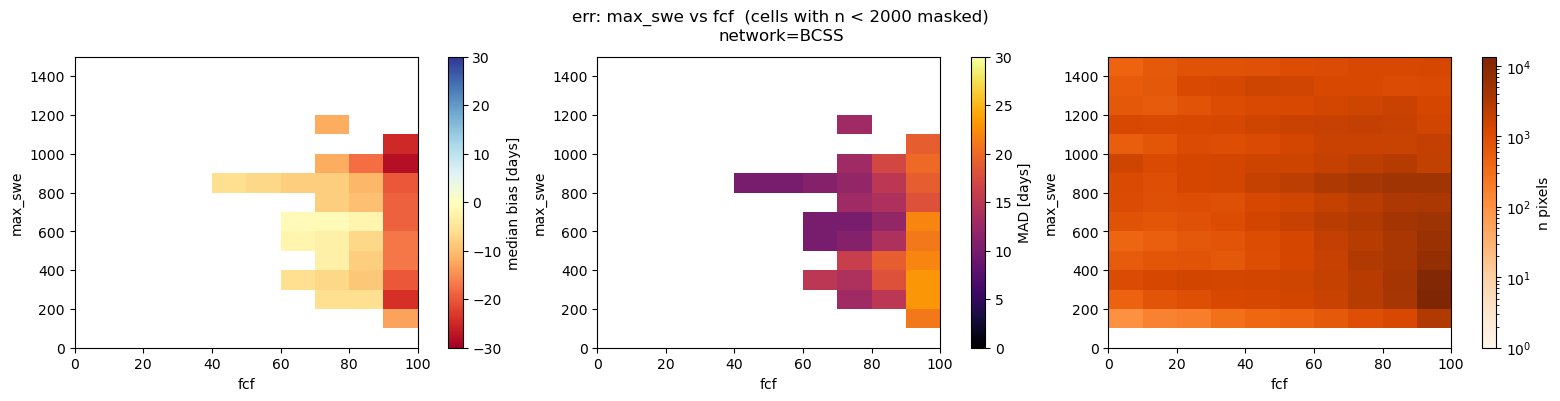

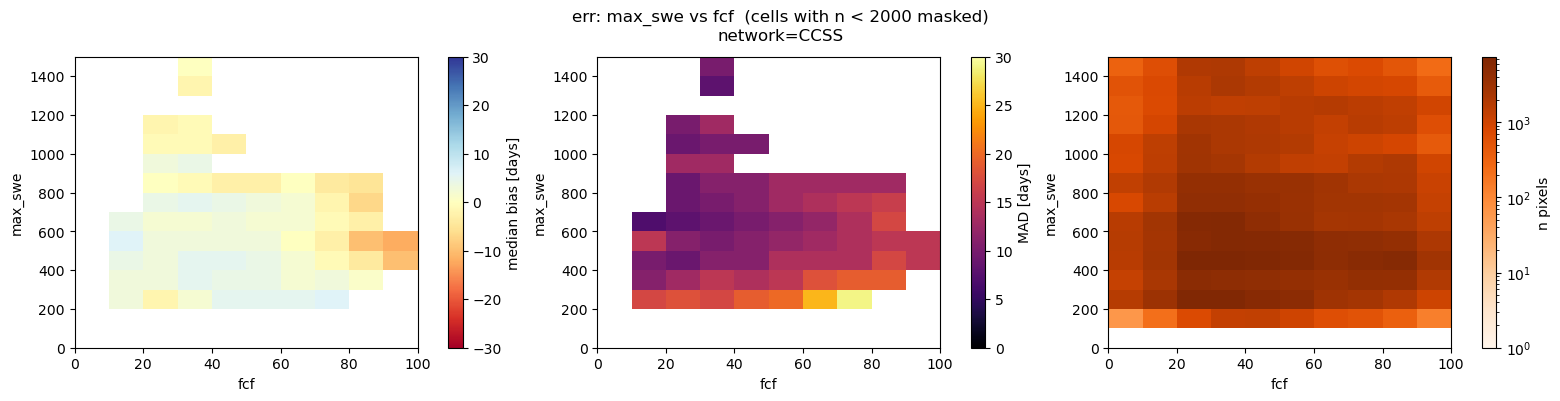

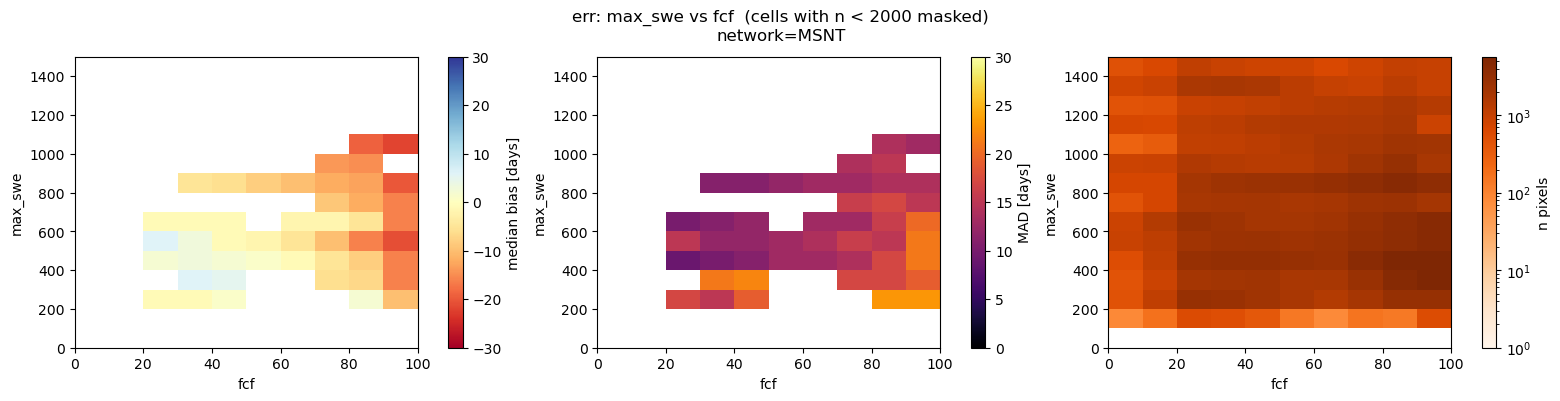

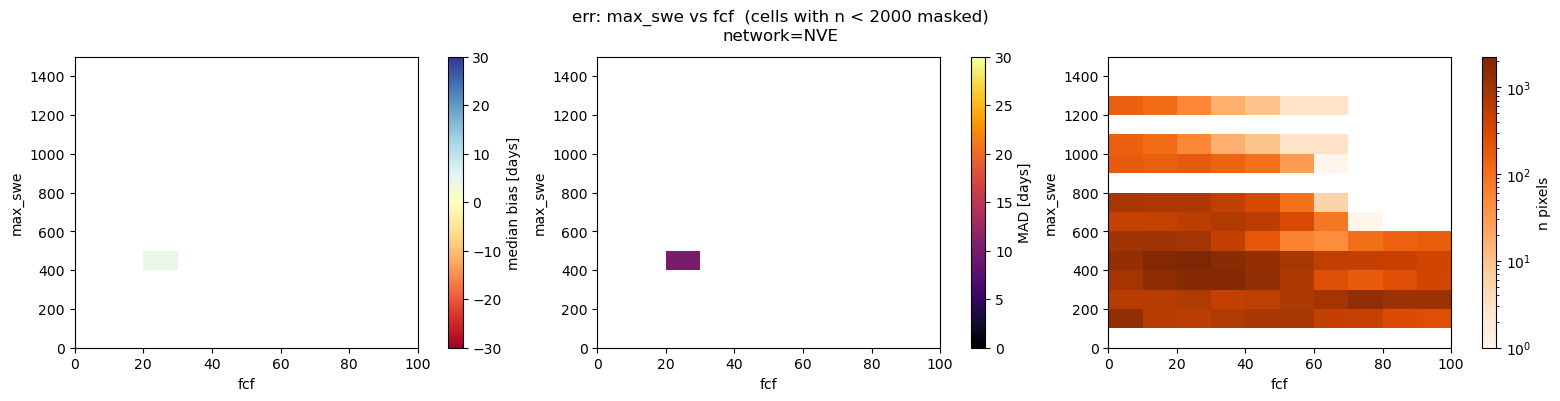

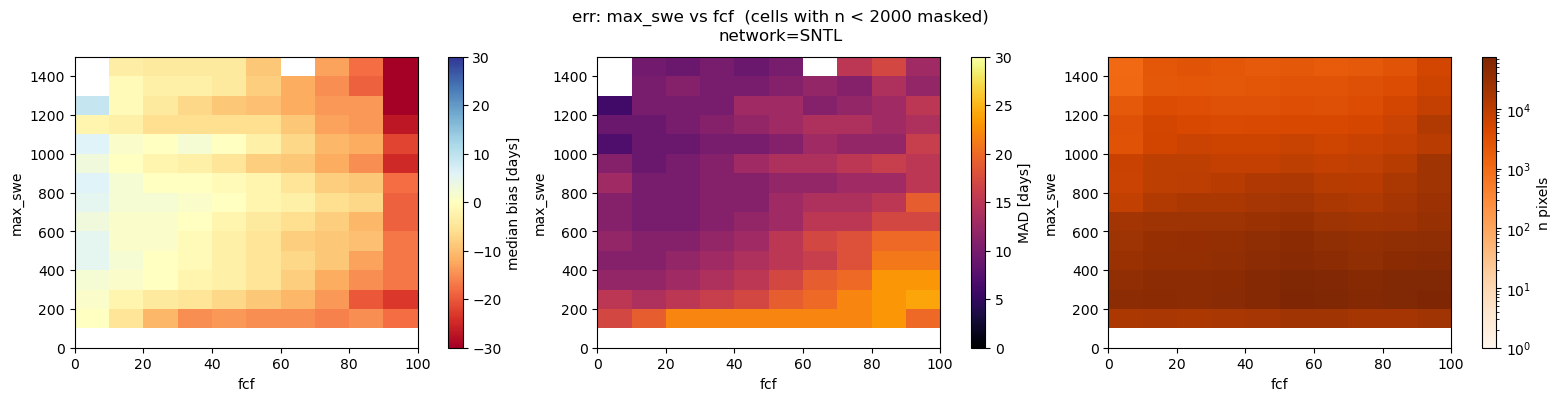

In [15]:
# --- categorical conditioning: fcf x max_swe map, faceted by network ----------
for nw_code, nw_name in NETWORK_NAMES.items():
    sub_nw = master_df[master_df["network"] == nw_code]
    if len(sub_nw) < 2000:
        continue
    print(f"network {nw_name}: {len(sub_nw):,} px")
    _ = binned_2d(sub_nw, "fcf", "max_swe",
                  np.arange(0, 101, 10), np.arange(0, 1600, 100), subtitle=f"network={nw_name}")

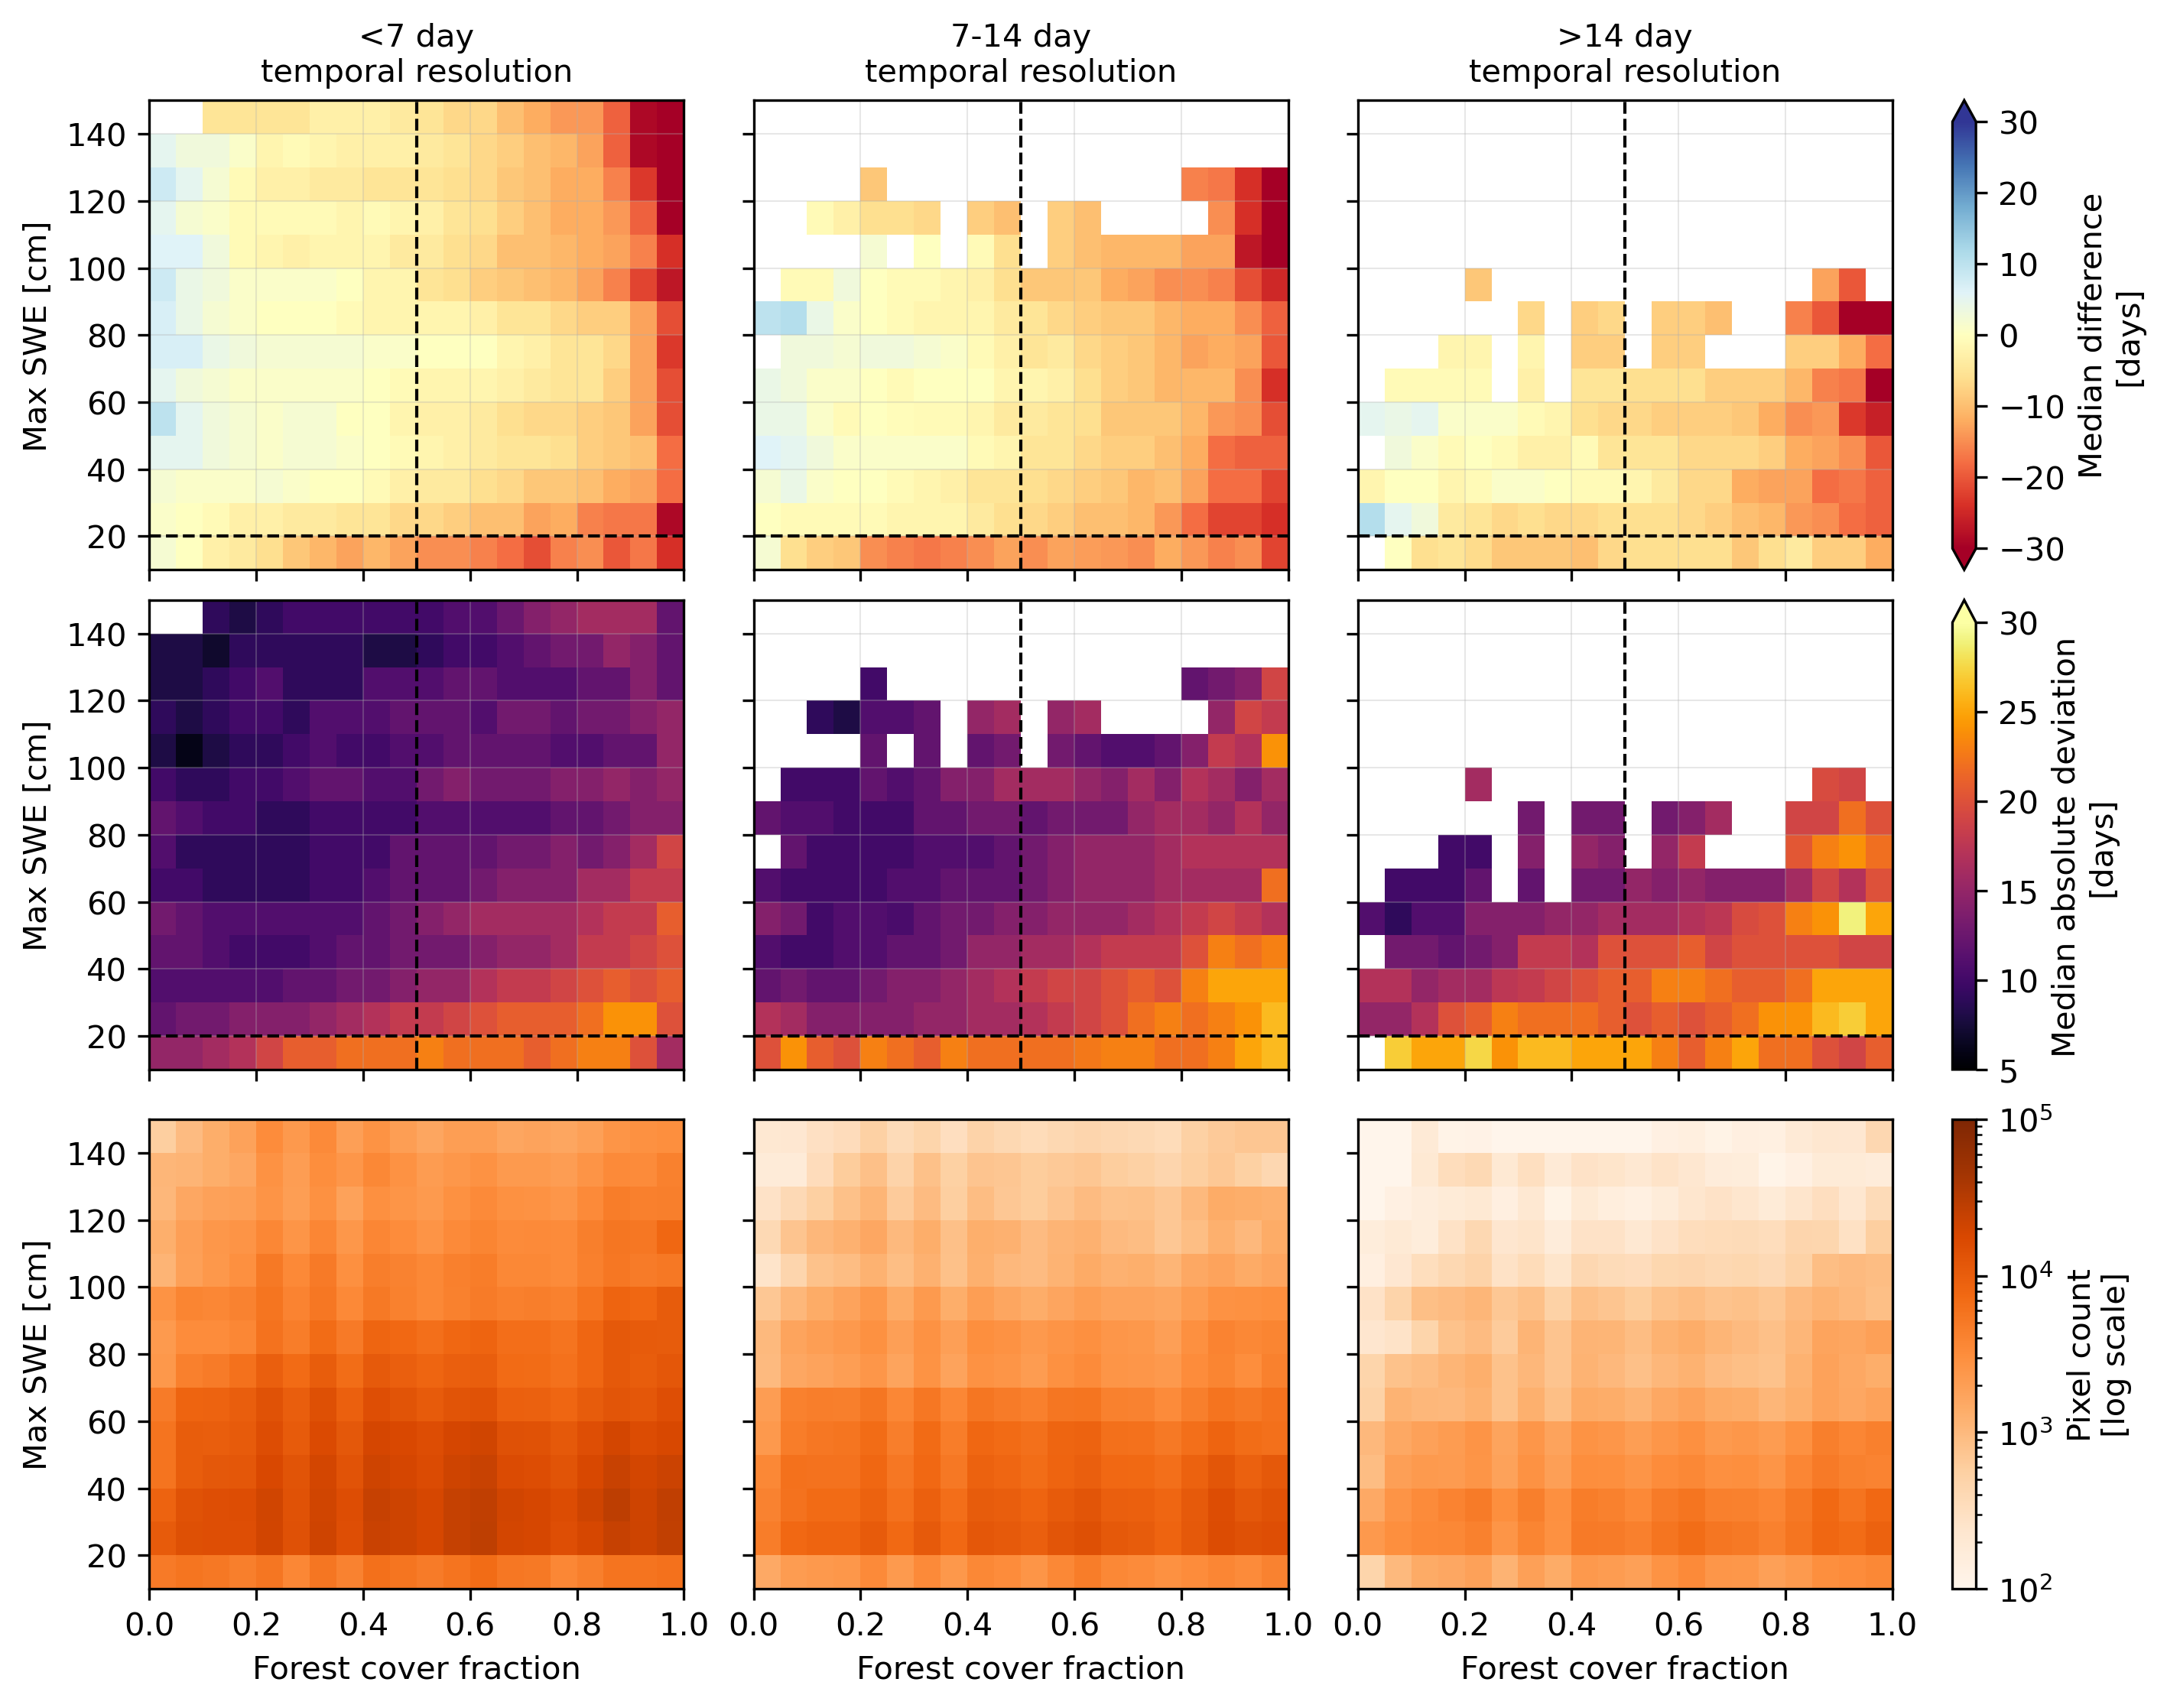

In [16]:
# fcf x max_swe binned stats, split by temporal resolution group (paper-figure style)

# FCF is stored 0–100; normalise to 0–1 fraction for the plot
fcf_arr = master_df["fcf"].values / 100.0

# max_SWE is in mm; convert to cm (figure y-axis label is cm)
swe_arr = master_df["max_swe"].values / 10.0

# Bin edges
fcf_bins = np.arange(0, 1.05, 0.05)   # 0–1 in 0.05 steps  (x-axis)
swe_bins = np.arange(10, 160, 10)      # 0–200 cm in 10 cm steps (y-axis)

FCF_THRESH = 0.5    # vertical dashed line
SWE_THRESH = 20.0   # horizontal dashed line [cm]
MIN_N      = 1000   # mask cells with fewer pixel-samples

BIAS_LIM = 30
MAD_LIM  = 30

tres_groups = [
    (master_df["temp_res"] < 7,
     "<7 day\ntemporal resolution"),
    ((master_df["temp_res"] >= 7) & (master_df["temp_res"] <= 14),
     "7-14 day\ntemporal resolution"),
    (master_df["temp_res"] > 14,
     ">14 day\ntemporal resolution"),
]

fig, axs = plt.subplots(3, 3, figsize=(14/1.5, 11/1.5),
                         layout="constrained", sharex=True, sharey=True, dpi=300)

row_ims = [None, None, None]

for col, (mask, col_title) in enumerate(tres_groups):
    m = mask.values
    tmp = pd.DataFrame({
        "fcf": pd.cut(fcf_arr[m], fcf_bins),
        "swe": pd.cut(swe_arr[m], swe_bins),
        "err": master_df["err"].values[m],
    })
    gb  = tmp.groupby(["swe", "fcf"], observed=False)["err"]

    cnt = gb.size().unstack().astype(float)
    med = gb.median().unstack().where(cnt >= MIN_N)
    mad = gb.agg(lambda s: (s - s.median()).abs().median()).unstack().where(cnt >= MIN_N)

    im0 = axs[0, col].pcolormesh(fcf_bins, swe_bins, med.values,
                                   cmap="RdYlBu", vmin=-BIAS_LIM, vmax=BIAS_LIM)
    im1 = axs[1, col].pcolormesh(fcf_bins, swe_bins, mad.values,
                                   cmap="inferno", vmin=5, vmax=MAD_LIM)
    im2 = axs[2, col].pcolormesh(fcf_bins, swe_bins,
                                   cnt.where(cnt > 0).values,
                                   cmap="Oranges",
                                   norm=LogNorm(vmin=1e2, vmax=1e5))


    for row in range(2):
        axs[row, col].axvline(FCF_THRESH, color="k", lw=1.0, ls="--")
        axs[row, col].axhline(SWE_THRESH, color="k", lw=1.0, ls="--")

        axs[row, col].grid(True, which="both", alpha=0.3, linewidth=0.5)

    axs[0, col].set_title(col_title, fontsize=10)
    row_ims = [im0, im1, im2]    # use last column images for colorbars (same limits)

for col in range(3):
    axs[2, col].set_xlabel("Forest cover fraction")
for row in range(3):
    axs[row, 0].set_ylabel("Max SWE [cm]")

fig.colorbar(row_ims[0], ax=axs[0, :], label="Median difference\n[days]",
             extend="both", pad=0.02)
fig.colorbar(row_ims[1], ax=axs[1, :], label="Median absolute deviation\n[days]",
             extend="max",  pad=0.02)
fig.colorbar(row_ims[2], ax=axs[2, :], label="Pixel count\n[log scale]", pad=0.02)

fig.savefig("figures/pixelwise_performance_analysis.png", dpi=300, bbox_inches="tight")

In [17]:
master_df

,fcf,temp_res,max_swe,radius,worldcover,snow_class,network,latitude,longitude,sar_minus_station_100pct_timing,sar_minus_station_99pct_timing,sar_minus_station_95pct_timing,sar_minus_station_90pct_timing,sar_minus_station_50pct_timing,station_idx,water_year,err,abs_err
0,2.0,7.8,381.00000,989.545349,30.0,5.0,4,40.357201,-116.864700,24.0,24.0,21.0,18.0,-19.0,0,2017,21.0,21.0
1,6.0,8.0,381.00000,973.242004,30.0,5.0,4,40.357201,-116.864700,6.0,6.0,3.0,0.0,-37.0,0,2017,3.0,3.0
2,10.0,7.1,381.00000,963.327576,30.0,6.0,4,40.357201,-116.864700,6.0,6.0,3.0,0.0,-37.0,0,2017,3.0,3.0
3,11.0,7.2,381.00000,960.000000,20.0,6.0,4,40.357201,-116.864700,36.0,36.0,33.0,30.0,-7.0,0,2017,33.0,33.0
4,11.0,7.3,381.00000,963.327576,20.0,6.0,4,40.357201,-116.864700,66.0,66.0,63.0,60.0,23.0,0,2017,63.0,63.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4196216,86.0,6.8,1127.76001,963.327576,10.0,3.0,1,39.135574,-120.218681,-10.0,-11.0,-19.0,-22.0,-41.0,1209,2024,-19.0,19.0
4196217,77.0,6.8,1127.76001,960.000000,10.0,3.0,1,39.135574,-120.218681,-10.0,-11.0,-19.0,-22.0,-41.0,1209,2024,-19.0,19.0
4196218,78.0,6.6,1127.76001,963.327576,10.0,3.0,1,39.135574,-120.218681,2.0,1.0,-7.0,-10.0,-29.0,1209,2024,-7.0,7.0
4196219,84.0,6.6,1127.76001,973.242004,10.0,3.0,1,39.135574,-120.218681,-4.0,-5.0,-13.0,-16.0,-35.0,1209,2024,-13.0,13.0


In [18]:
states_gdf = gpd.read_file('http://eric.clst.org/assets/wiki/uploads/Stuff/gz_2010_us_040_00_5m.json')

WUS_gdf = states_gdf[~states_gdf['NAME'].isin(['Alaska'])]

alaska_gdf = states_gdf[states_gdf['NAME'].isin(['Alaska'])]

world_gdf = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

bc_gdf = world_gdf[world_gdf['NAME'].isin(['Canada'])]

norway_gdf = world_gdf[world_gdf['NAME'].isin(['Norway'])]

nepal_gdf = world_gdf[world_gdf['NAME'].isin(['Nepal'])]

<Axes: >

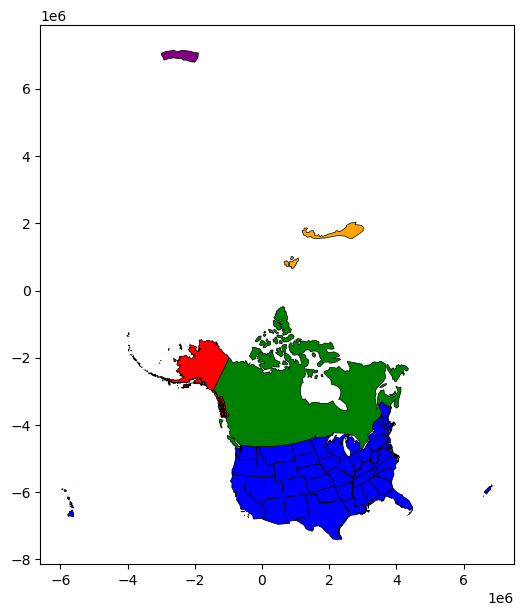

In [19]:
f,ax=plt.subplots(figsize=(12,7))
map_crs = "+proj=stere +lat_0=90 +lat_ts=71 +lon_0=-115 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"

WUS_gdf.to_crs(map_crs).plot(ax=ax, color='blue', edgecolor='black', linewidth=0.5)
alaska_gdf.to_crs(map_crs).plot(ax=ax, color='red', edgecolor='black', linewidth=0.5)
bc_gdf.to_crs(map_crs).plot(ax=ax, color='green', edgecolor='black',linewidth=0.5)
norway_gdf.to_crs(map_crs).plot(ax=ax, color='orange', edgecolor='black',linewidth=0.5)
nepal_gdf.to_crs(map_crs).plot(ax=ax, color='purple', edgecolor='black', linewidth=0.5)

In [20]:
# --- classify each master_df pixel as inside / outside the WUS -----------------
# WUS_gdf = all US states except Alaska (defined above)
wus_union = WUS_gdf.to_crs("EPSG:4326").union_all()
minx, miny, maxx, maxy = wus_union.bounds

# cheap bounding-box prefilter, then precise point-in-polygon only on candidates
in_bbox = (master_df["longitude"].between(minx, maxx)
           & master_df["latitude"].between(miny, maxy))

master_df["in_wus"] = False
cand = master_df.loc[in_bbox, ["longitude", "latitude"]]
pts = gpd.GeoSeries(gpd.points_from_xy(cand["longitude"], cand["latitude"]),
                    index=cand.index, crs="EPSG:4326")
master_df.loc[cand.index, "in_wus"] = pts.within(wus_union).values

WUS_df     = master_df[master_df["in_wus"]]
non_WUS_df = master_df[~master_df["in_wus"]]
print(f"WUS: {len(WUS_df):,} px   non-WUS: {len(non_WUS_df):,} px")


# --- reusable version of the paper-figure pixelwise-performance plot ------------
def plot_pixelwise_performance(df, save_path=None, suptitle=None, min_n=1000):
    """fcf x max_SWE binned bias / MAD / count heatmaps, split by temporal-resolution group.

    Same figure as the master_df version above, but takes any subset `df`.
    """
    # FCF is stored 0-100; normalise to 0-1 fraction for the plot
    fcf_arr = df["fcf"].values / 100.0
    # max_SWE is in mm; convert to cm (figure y-axis label is cm)
    swe_arr = df["max_swe"].values / 10.0

    fcf_bins = np.arange(0, 1.05, 0.05)   # 0-1 in 0.05 steps  (x-axis)
    swe_bins = np.arange(10, 160, 10)     # 0-200 cm in 10 cm steps (y-axis)

    FCF_THRESH = 0.5    # vertical dashed line
    SWE_THRESH = 20.0   # horizontal dashed line [cm]
    BIAS_LIM   = 30
    MAD_LIM    = 30

    tres_groups = [
        (df["temp_res"] < 7,
         "<7 day\ntemporal resolution"),
        ((df["temp_res"] >= 7) & (df["temp_res"] <= 14),
         "7-14 day\ntemporal resolution"),
        (df["temp_res"] > 14,
         ">14 day\ntemporal resolution"),
    ]

    fig, axs = plt.subplots(3, 3, figsize=(14/1.5, 11/1.5),
                            layout="constrained", sharex=True, sharey=True, dpi=300)

    row_ims = [None, None, None]

    for col, (mask, col_title) in enumerate(tres_groups):
        m = mask.values
        tmp = pd.DataFrame({
            "fcf": pd.cut(fcf_arr[m], fcf_bins),
            "swe": pd.cut(swe_arr[m], swe_bins),
            "err": df["err"].values[m],
        })
        gb  = tmp.groupby(["swe", "fcf"], observed=False)["err"]

        cnt = gb.size().unstack().astype(float)
        med = gb.median().unstack().where(cnt >= min_n)
        mad = gb.agg(lambda s: (s - s.median()).abs().median()).unstack().where(cnt >= min_n)

        im0 = axs[0, col].pcolormesh(fcf_bins, swe_bins, med.values,
                                     cmap="RdYlBu", vmin=-BIAS_LIM, vmax=BIAS_LIM)
        im1 = axs[1, col].pcolormesh(fcf_bins, swe_bins, mad.values,
                                     cmap="inferno", vmin=5, vmax=MAD_LIM)
        im2 = axs[2, col].pcolormesh(fcf_bins, swe_bins,
                                     cnt.where(cnt > 0).values,
                                     cmap="Oranges",
                                     norm=LogNorm(vmin=1e2, vmax=1e5))

        for row in range(2):
            axs[row, col].axvline(FCF_THRESH, color="k", lw=1.0, ls="--")
            axs[row, col].axhline(SWE_THRESH, color="k", lw=1.0, ls="--")
            axs[row, col].grid(True, which="both", alpha=0.3, linewidth=0.5)

        axs[0, col].set_title(col_title, fontsize=10)
        row_ims = [im0, im1, im2]    # use last column images for colorbars (same limits)

    for col in range(3):
        axs[2, col].set_xlabel("Forest cover fraction")
    for row in range(3):
        axs[row, 0].set_ylabel("Max SWE [cm]")

    fig.colorbar(row_ims[0], ax=axs[0, :], label="Median difference\n[days]",
                 extend="both", pad=0.02)
    fig.colorbar(row_ims[1], ax=axs[1, :], label="Median absolute deviation\n[days]",
                 extend="max",  pad=0.02)
    fig.colorbar(row_ims[2], ax=axs[2, :], label="Pixel count\n[log scale]", pad=0.02)

    if suptitle:
        fig.suptitle(suptitle, fontweight="bold")
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

WUS: 3,565,412 px   non-WUS: 630,809 px


MIN_N for WUS: 850 (proportional to pixel count)


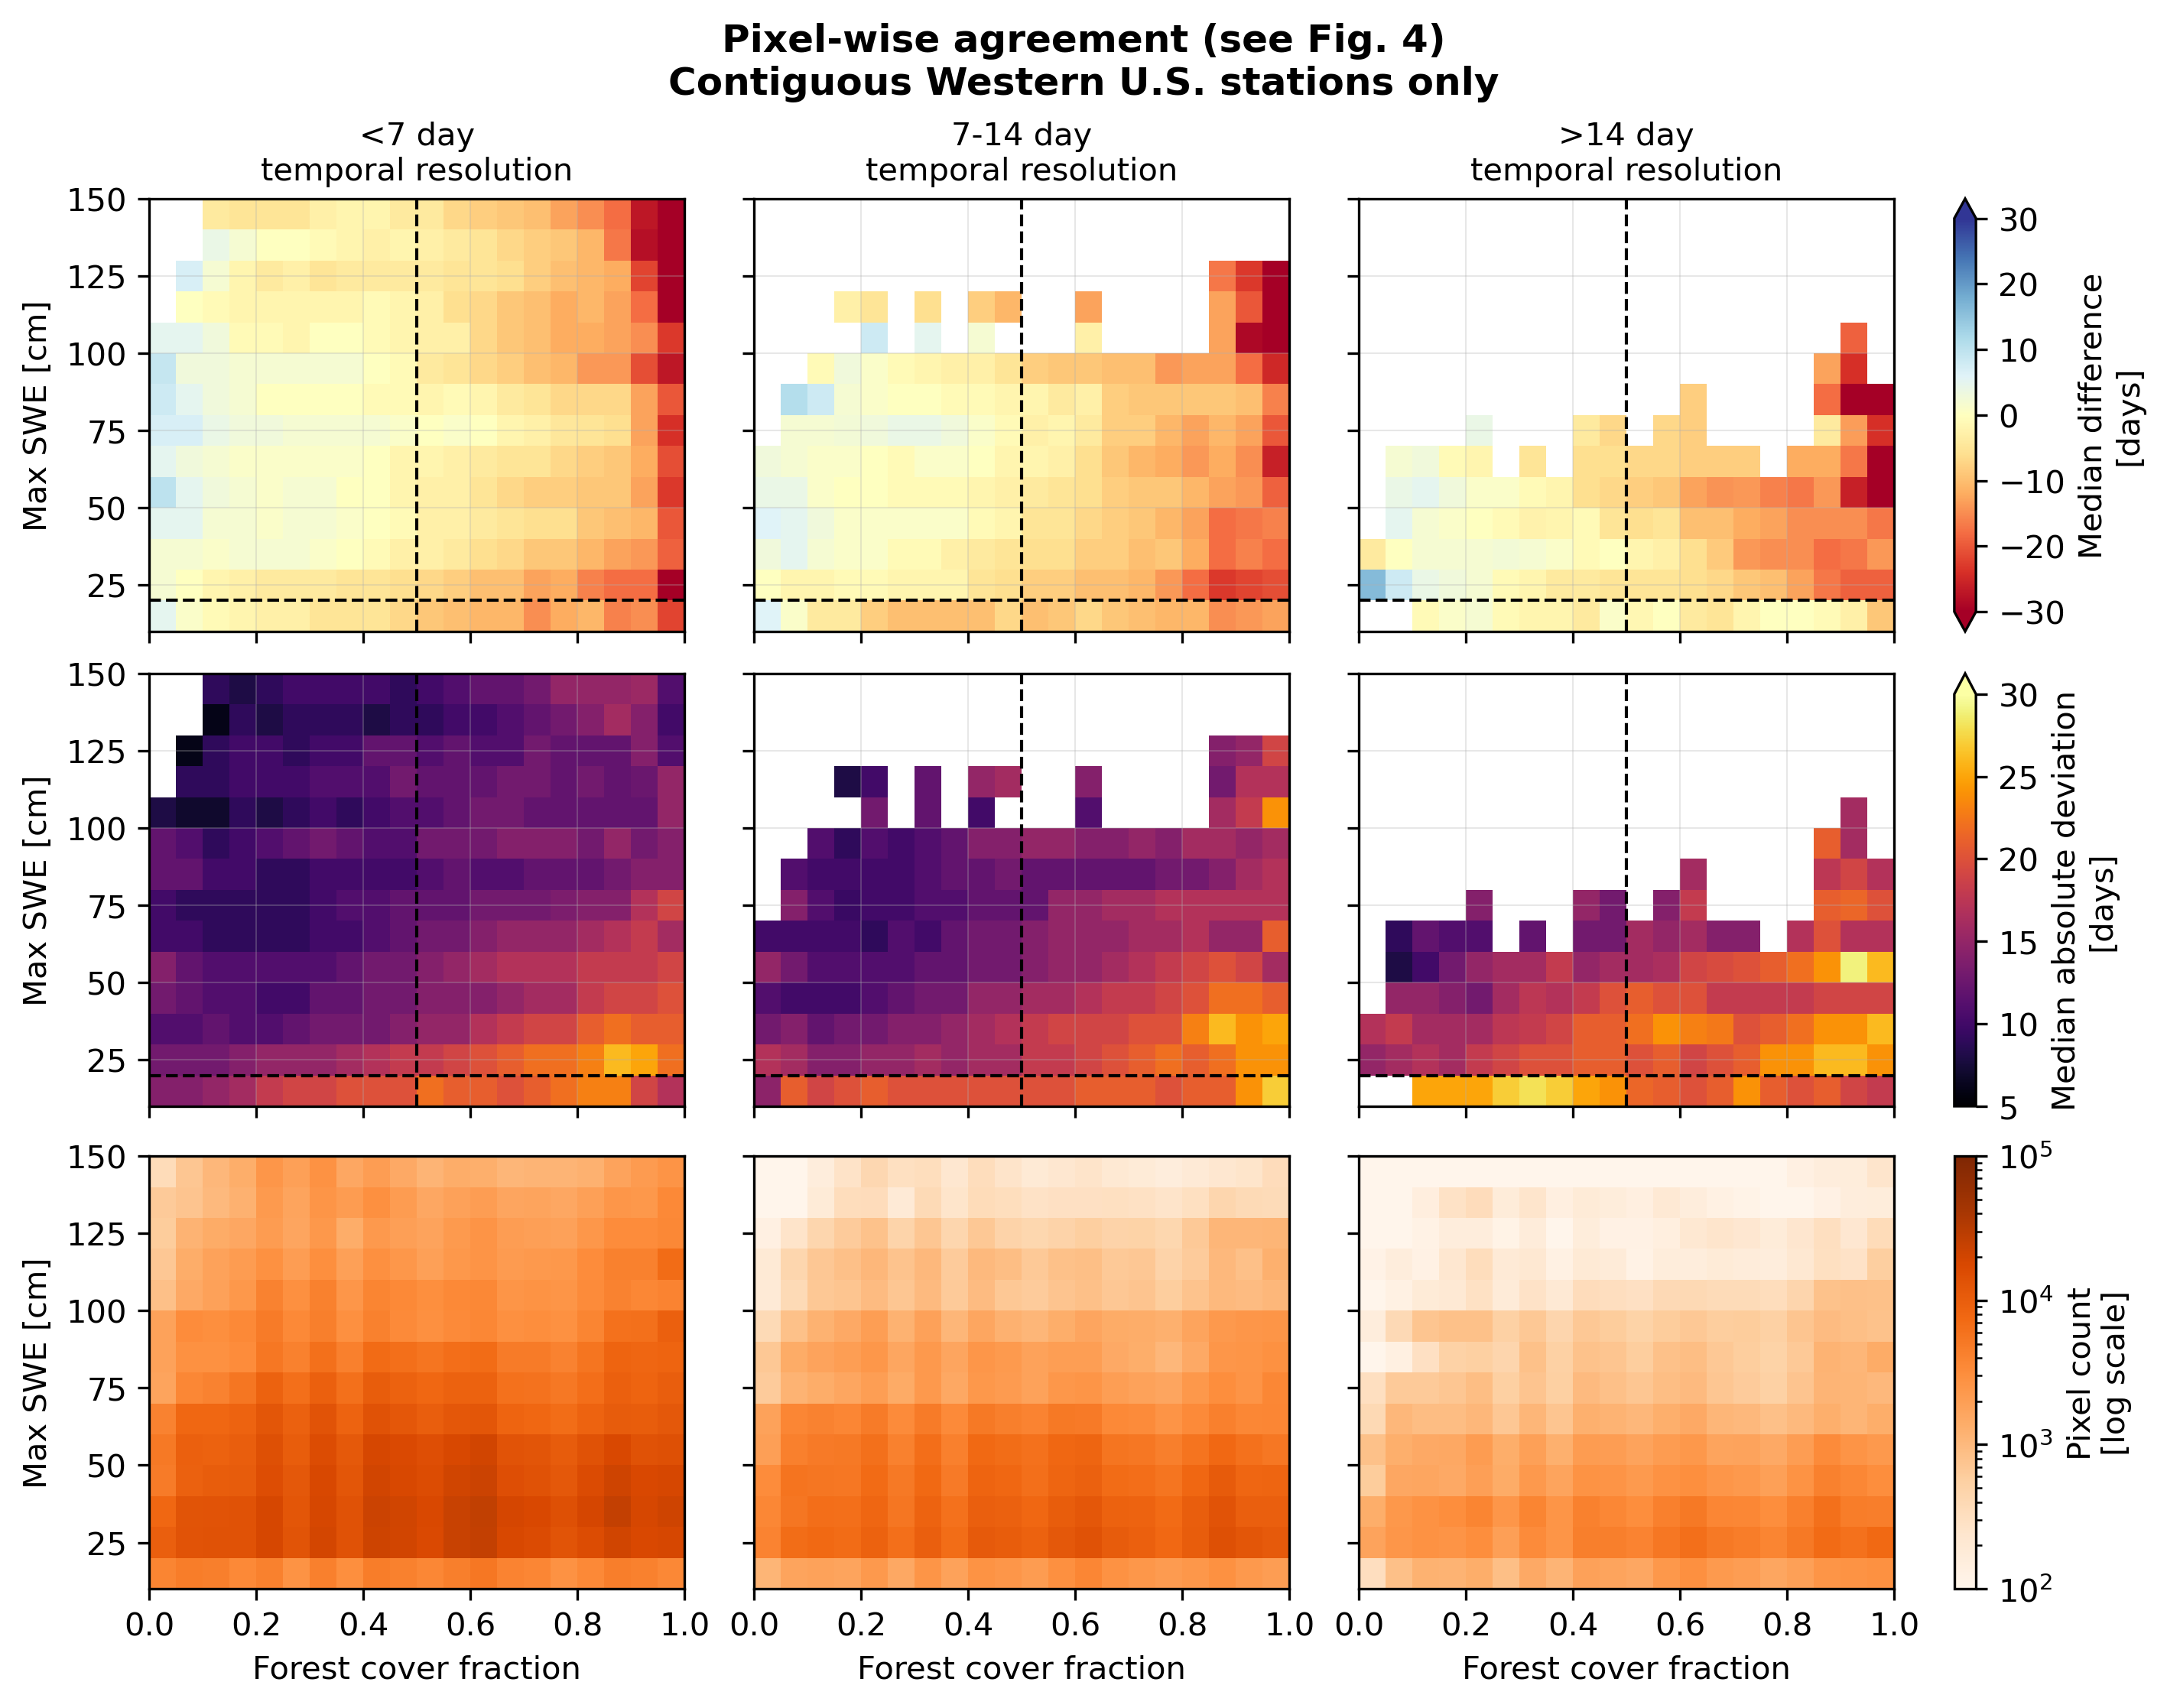

In [21]:
# now make a version of pixelwise_performance_analysis.png in this cell for WUS

MIN_N = 1000 * (len(WUS_df) / (len(WUS_df)+len(non_WUS_df)))
print(f"MIN_N for WUS: {MIN_N:.0f} (proportional to pixel count)")
plot_pixelwise_performance(
    WUS_df,
    save_path="figures/pixelwise_performance_analysis_WUS.png",
    suptitle=f"Pixel-wise agreement (see Fig. 4)\nContiguous Western U.S. stations only",
    min_n=MIN_N,
)


MIN_N for non-WUS: 500 (proportional to pixel count)


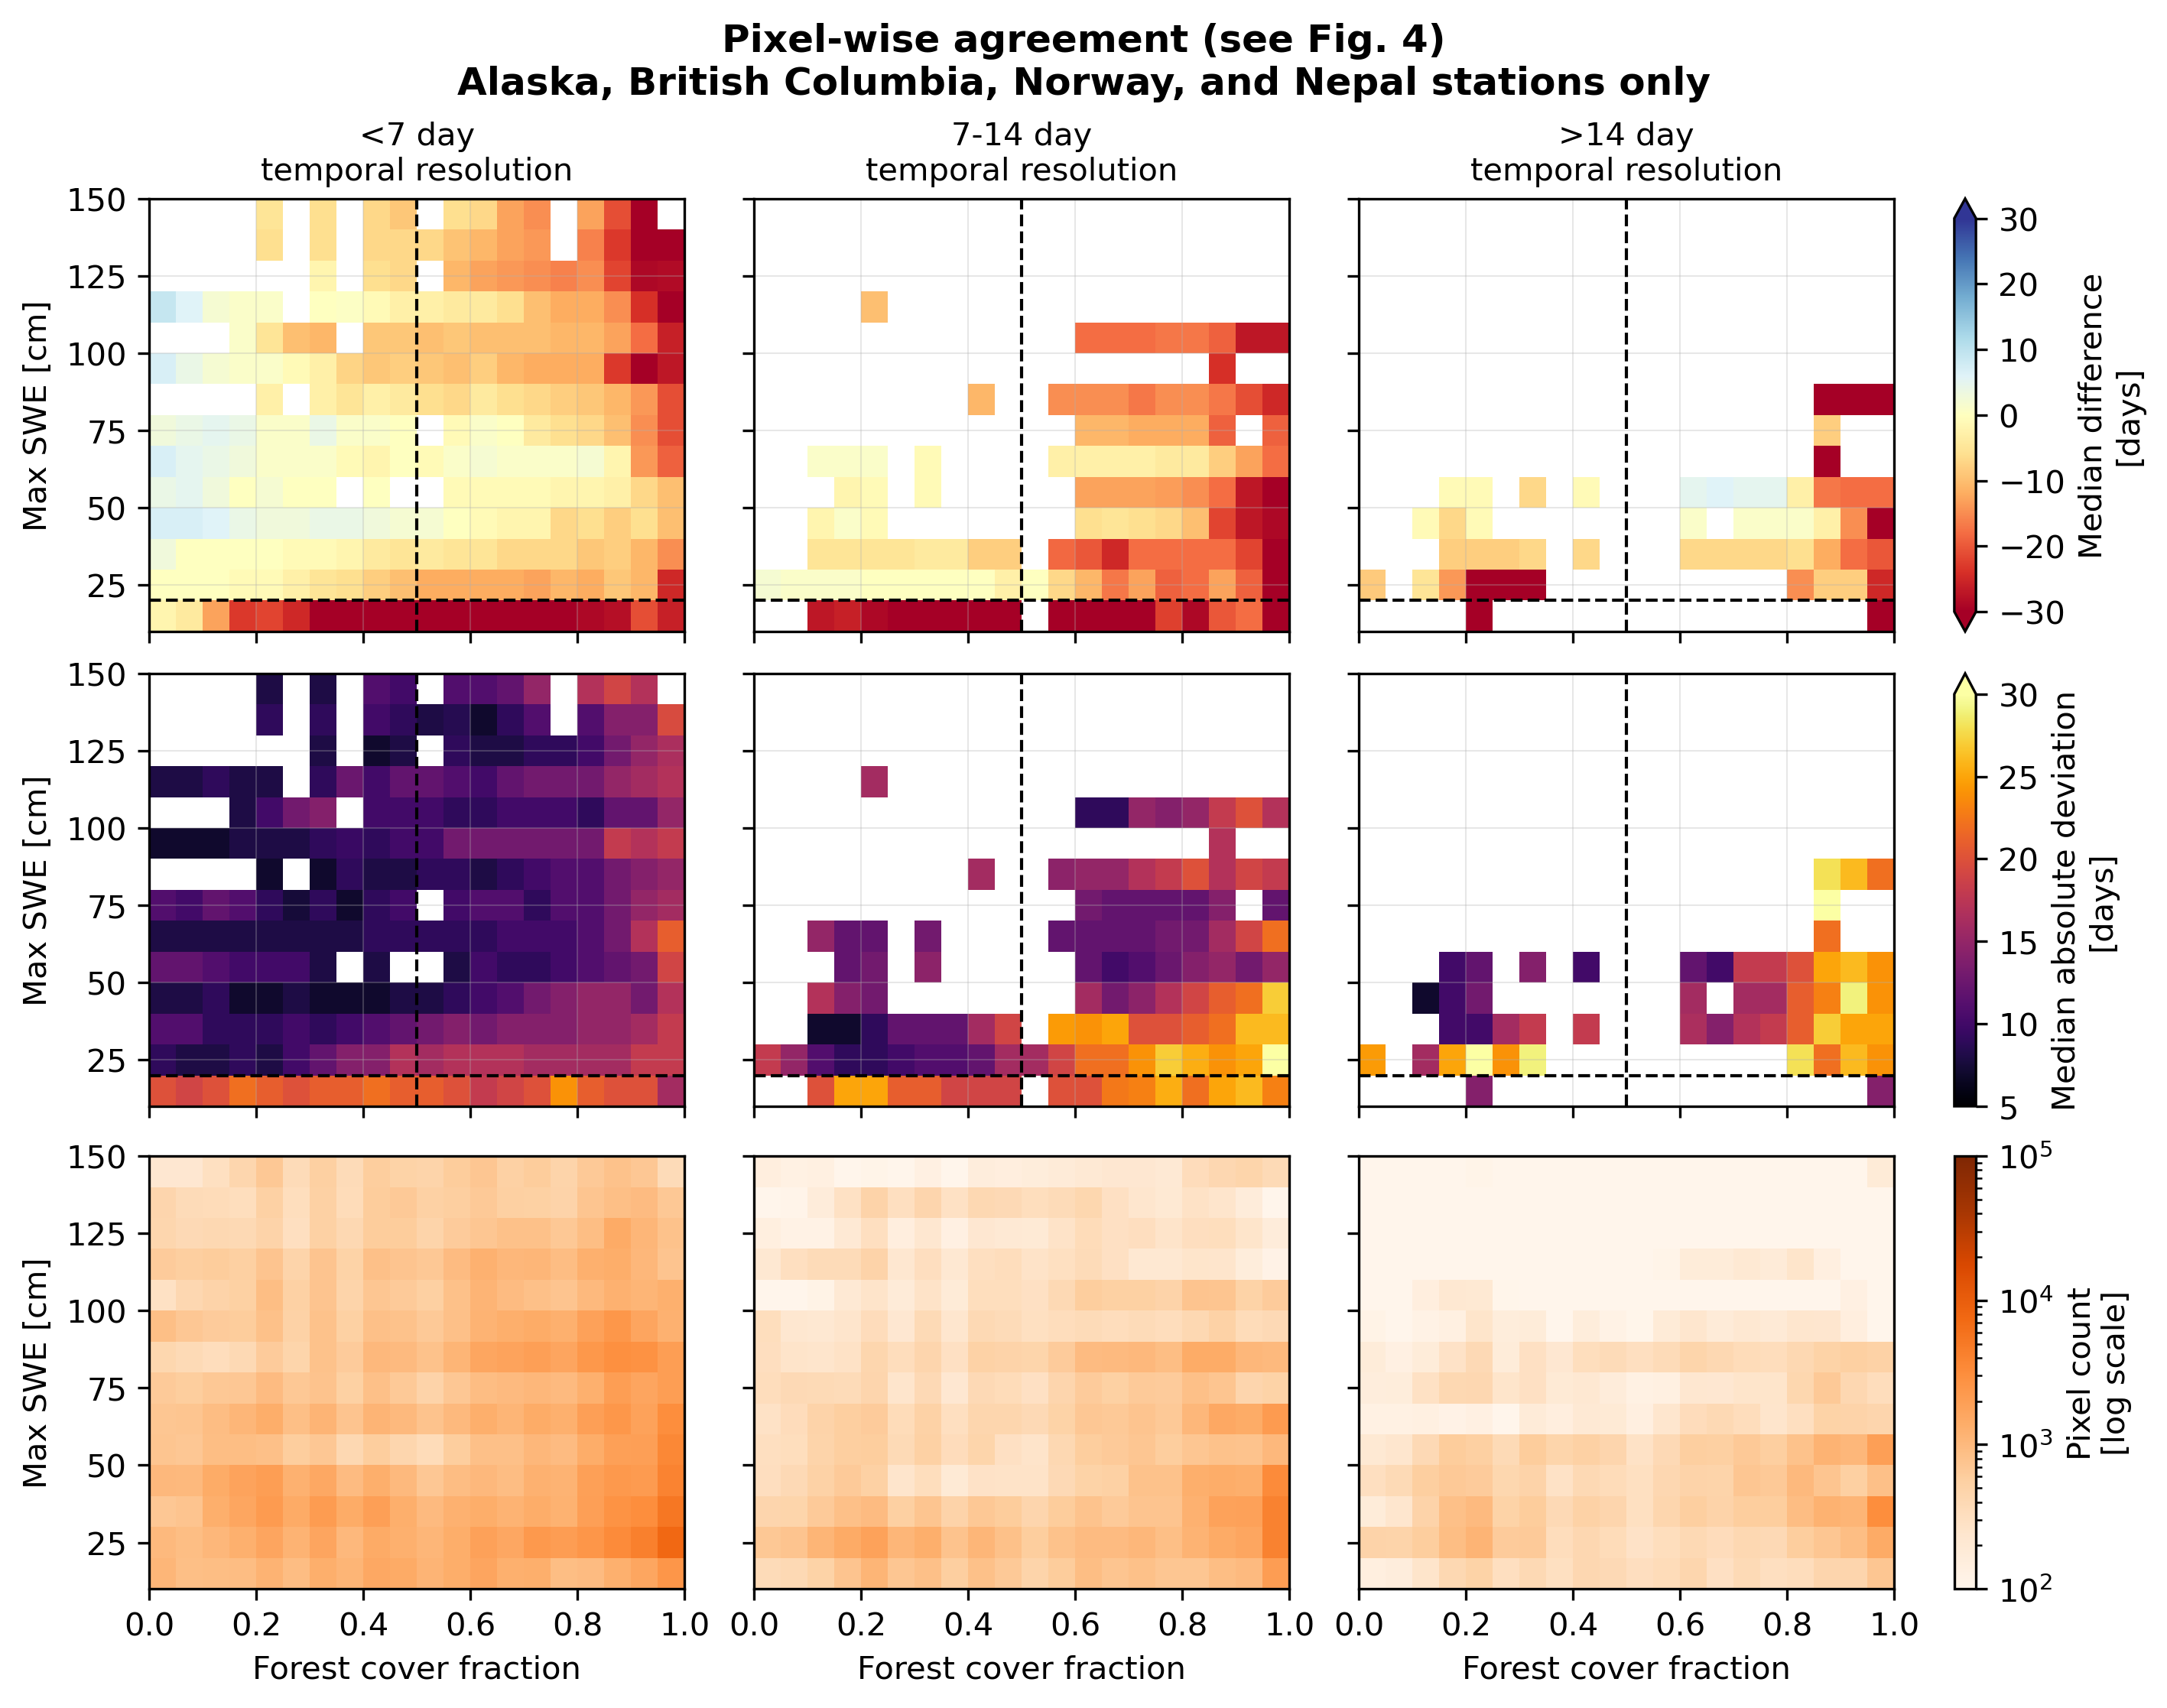

In [22]:
# now make a version of pixelwise_performance_analysis.png in this cell for non WUS
# MIN_N should be proportional to the number of pixels in the 
MIN_N = 1000 * (len(non_WUS_df) / (len(WUS_df)+len(non_WUS_df)))
MIN_N = 500
print(f"MIN_N for non-WUS: {MIN_N:.0f} (proportional to pixel count)")
plot_pixelwise_performance(
    non_WUS_df,
    save_path="figures/pixelwise_performance_analysis_nonWUS.png",
    suptitle=f"Pixel-wise agreement (see Fig. 4)\nAlaska, British Columbia, Norway, and Nepal stations only",
    min_n=MIN_N,
)


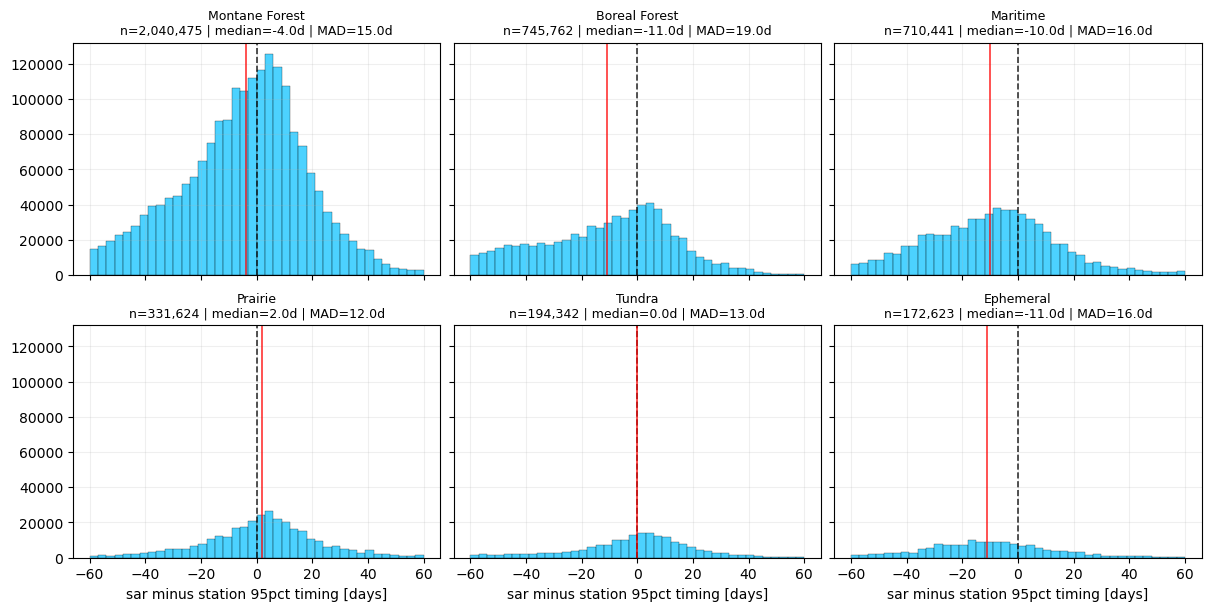

In [23]:
# make histograms of residuals for each snow classification
EXCLUDE_SNOW_CLASSES = {7, 8}  # Ice, Ocean

snow_class_counts = (
    master_df["snow_class"]
    .cat.remove_unused_categories()
    .value_counts()
)
snow_class_counts = snow_class_counts[
    ~snow_class_counts.index.isin(EXCLUDE_SNOW_CLASSES) & (snow_class_counts > 0)
]
snow_classes_present = snow_class_counts.index.tolist()  # sorted by count, descending

ncols = 3
nrows = int(np.ceil(len(snow_classes_present) / ncols))
bins = np.linspace(-60, 60, 41)

f, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows),
                       sharex=True, sharey=True, layout="constrained")
axs = np.atleast_1d(axs).flatten()

for ax, sc_code in zip(axs, snow_classes_present):
    vals = master_df.loc[master_df["snow_class"] == sc_code, "err"].dropna()
    med = vals.median()
    mad = (vals - med).abs().median()

    ax.hist(vals, bins=bins, color="deepskyblue", alpha=0.7, linewidth=0.3, edgecolor="black")
    ax.axvline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.axvline(med, color="red", linestyle="-", linewidth=1.2, alpha=0.8)
    ax.set_title(
        f"{SNOW_CLASS_NAMES[sc_code]}\n"
        f"n={len(vals):,} | median={med:.1f}d | MAD={mad:.1f}d",
        fontsize=9,
    )
    ax.grid(alpha=0.2)

for ax in axs[len(snow_classes_present):]:
    ax.set_visible(False)

for ax in axs[:len(snow_classes_present)]:
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel(f"{FOCUS.replace('_', ' ')} [days]")

#f.suptitle(f"Residual distributions by snow classification (sorted by n) — {FOCUS}", fontweight="bold")

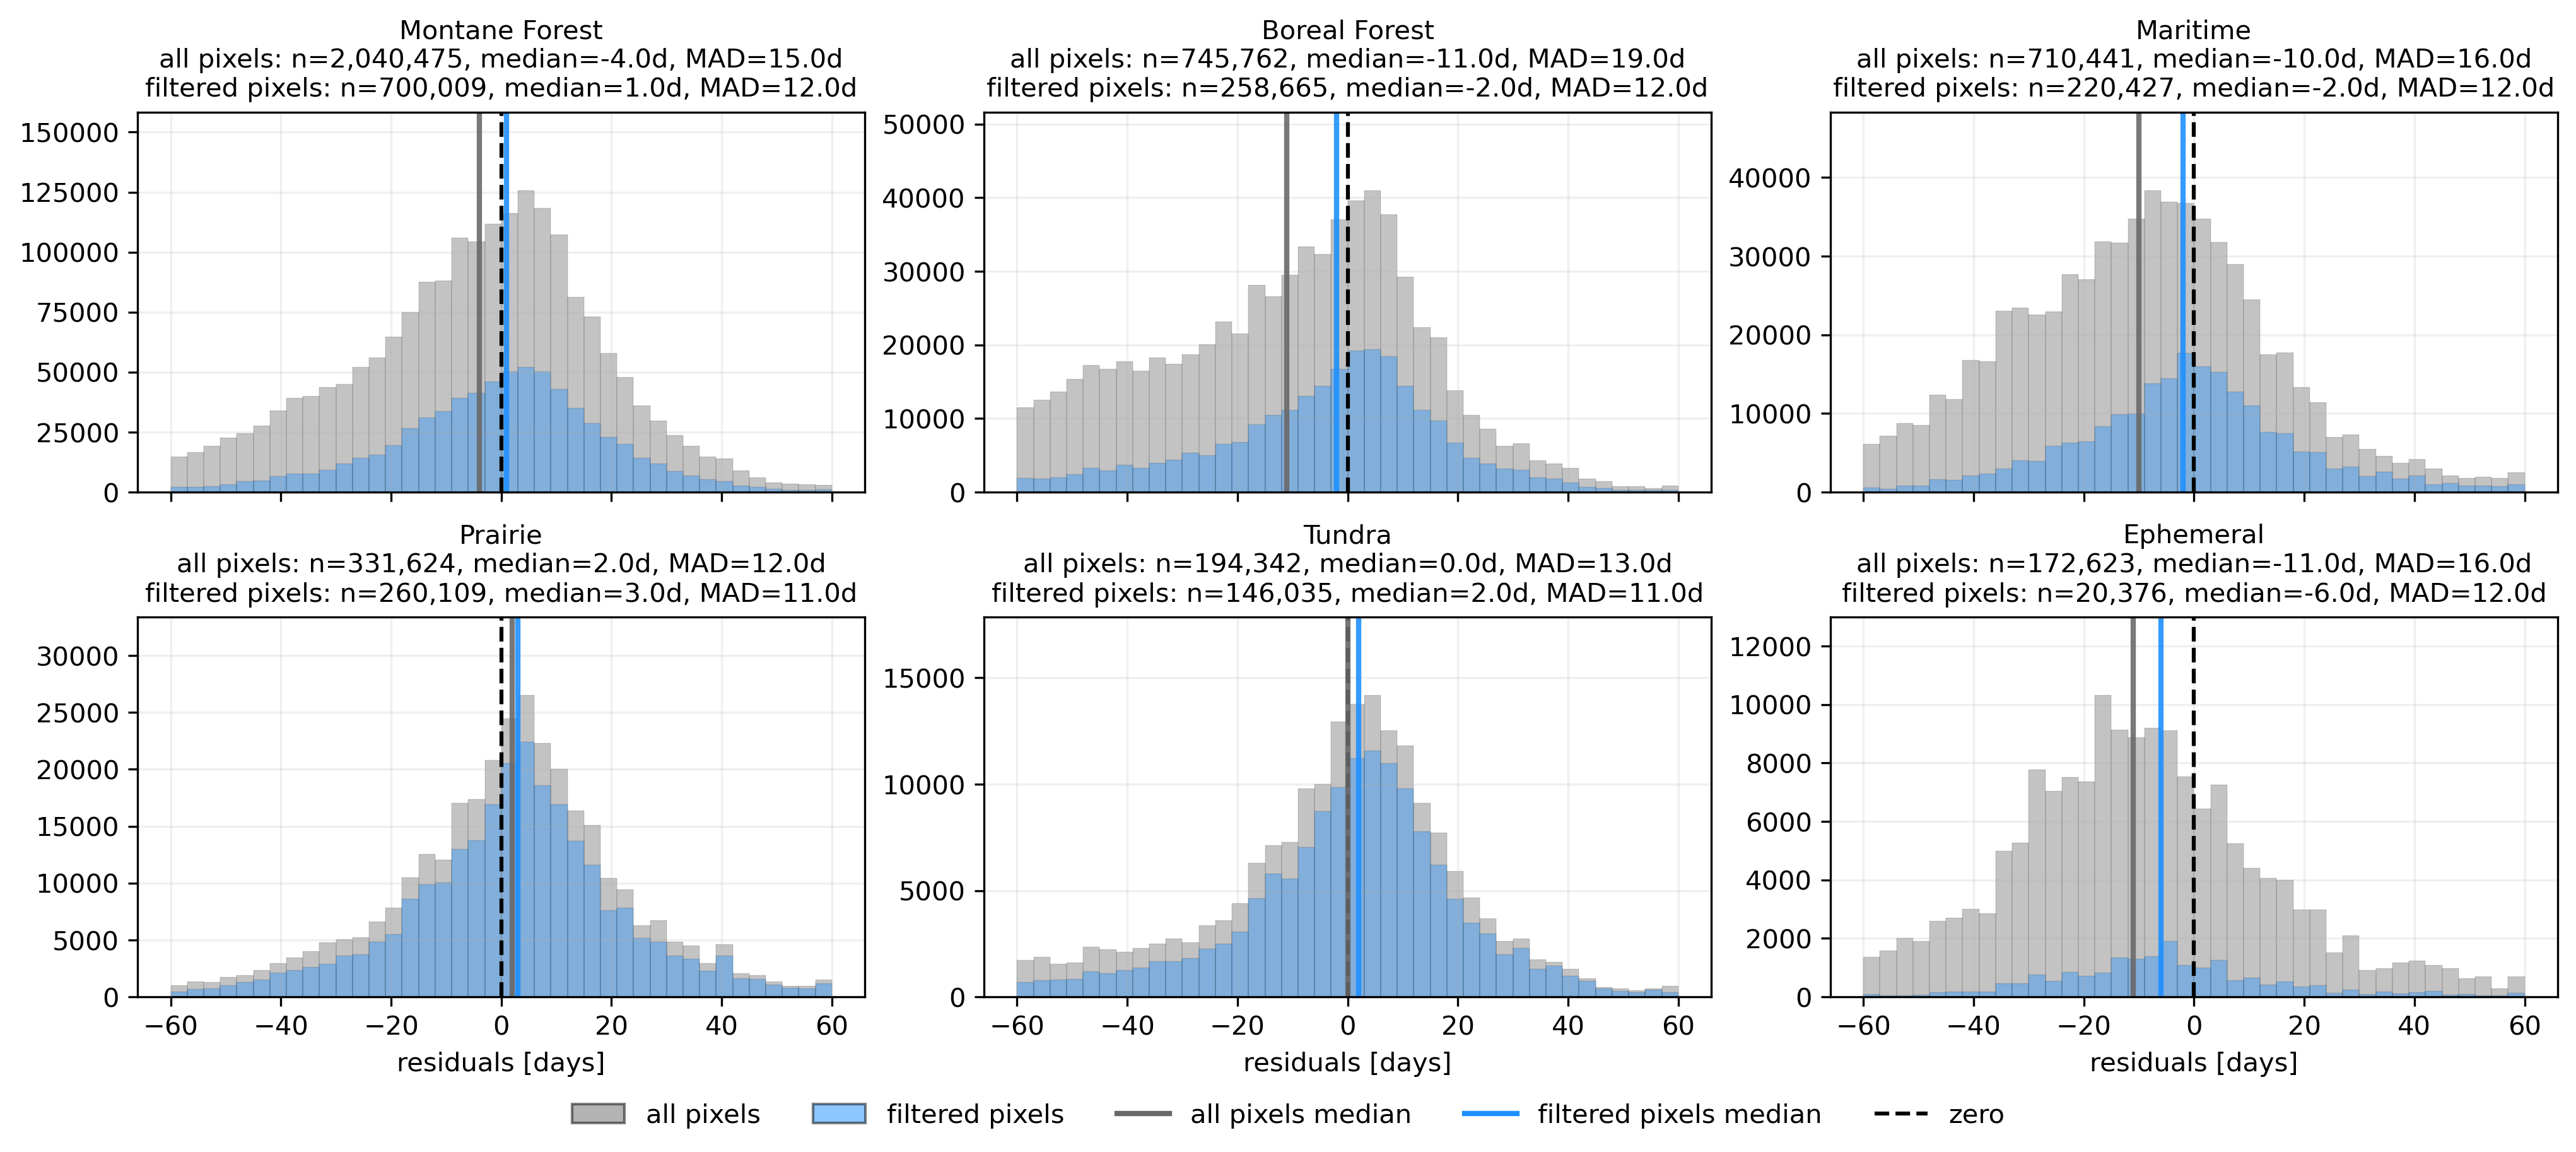

In [24]:
ALL_COLOR  = "dimgray"
GOOD_COLOR = "dodgerblue"

good_pixels = (
    (master_df["fcf"] / 100.0 <= FCF_THRESH)   # forest cover fraction <= 0.5
    & (master_df["temp_res"] < 14)             # temporal resolution < 14 days
    & (master_df["max_swe"] / 10.0 > SWE_THRESH)  # max SWE > 20 cm
)

ncols = 3
nrows = int(np.ceil(len(snow_classes_present) / ncols))
bins = np.linspace(-60, 60, 41)

f, axs = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3 * nrows),
                       sharex=True, sharey=False, layout="constrained", dpi=300)
axs = np.atleast_1d(axs).flatten()

for ax, sc_code in zip(axs, snow_classes_present):
    is_class = master_df["snow_class"] == sc_code

    all_vals = master_df.loc[is_class, "err"].dropna()
    all_med = all_vals.median()
    all_mad = (all_vals - all_med).abs().median()

    good_vals = master_df.loc[is_class & good_pixels, "err"].dropna()
    
    good_med = good_vals.median()
    good_mad = (good_vals - good_med).abs().median()

    ax.hist(all_vals, bins=bins, color=ALL_COLOR, alpha=0.4,
            linewidth=0.1, edgecolor="black", label="all pixels")
    ax.hist(good_vals, bins=bins, color=GOOD_COLOR, alpha=0.4,
            linewidth=0.1, edgecolor="black", label="good pixels")

    ax.axvline(0, color="black", linestyle="--", linewidth=1.5, alpha=1.0)
    ax.axvline(all_med, color=ALL_COLOR, linestyle="-", linewidth=2.0, alpha=0.9)
    ax.axvline(good_med, color=GOOD_COLOR, linestyle="-", linewidth=2.0, alpha=0.9)

    good_line = (
        f"filtered pixels: n={len(good_vals):,}, median={good_med:.1f}d, MAD={good_mad:.1f}d"
    )
    ax.set_title(
        f"{SNOW_CLASS_NAMES[sc_code]}\n"
        f"all pixels: n={len(all_vals):,}, median={all_med:.1f}d, MAD={all_mad:.1f}d\n"
        f"{good_line}",
        fontsize=10,
    )
    ax.grid(alpha=0.2)
    
    # get current y-axis limits and set it a bit higher by multiplying by 1.1 to avoid overlap with the title
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max * 1.2)

for ax in axs[len(snow_classes_present):]:
    ax.set_visible(False)

for ax in axs[:len(snow_classes_present)]:
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel("residuals [days]")
        
legend_handles = [
    Patch(facecolor=ALL_COLOR,  alpha=0.5, edgecolor="black", label="all pixels"),
    Patch(facecolor=GOOD_COLOR, alpha=0.5, edgecolor="black", label="filtered pixels"),
    Line2D([0], [0], color=ALL_COLOR,  lw=2.0, label="all pixels median"),
    Line2D([0], [0], color=GOOD_COLOR, lw=2.0, label="filtered pixels median"),
    Line2D([0], [0], color="black", lw=1.5, ls="--", label="zero"),
]
f.legend(handles=legend_handles, loc="outside lower center", ncol=5, frameon=False)

#f.suptitle(f"Residual distributions by snow classification: all vs. good pixels (sorted by n) — {FOCUS}", fontweight="bold")
f.savefig("figures/residuals_by_snow_class_all_vs_good_pixels.png", dpi=300, bbox_inches="tight")

173,577 of 4,196,221 residual samples (4.1%) fall in Ephemeral/Ice/other classes and are excluded from the % comparison (as in Table 1)


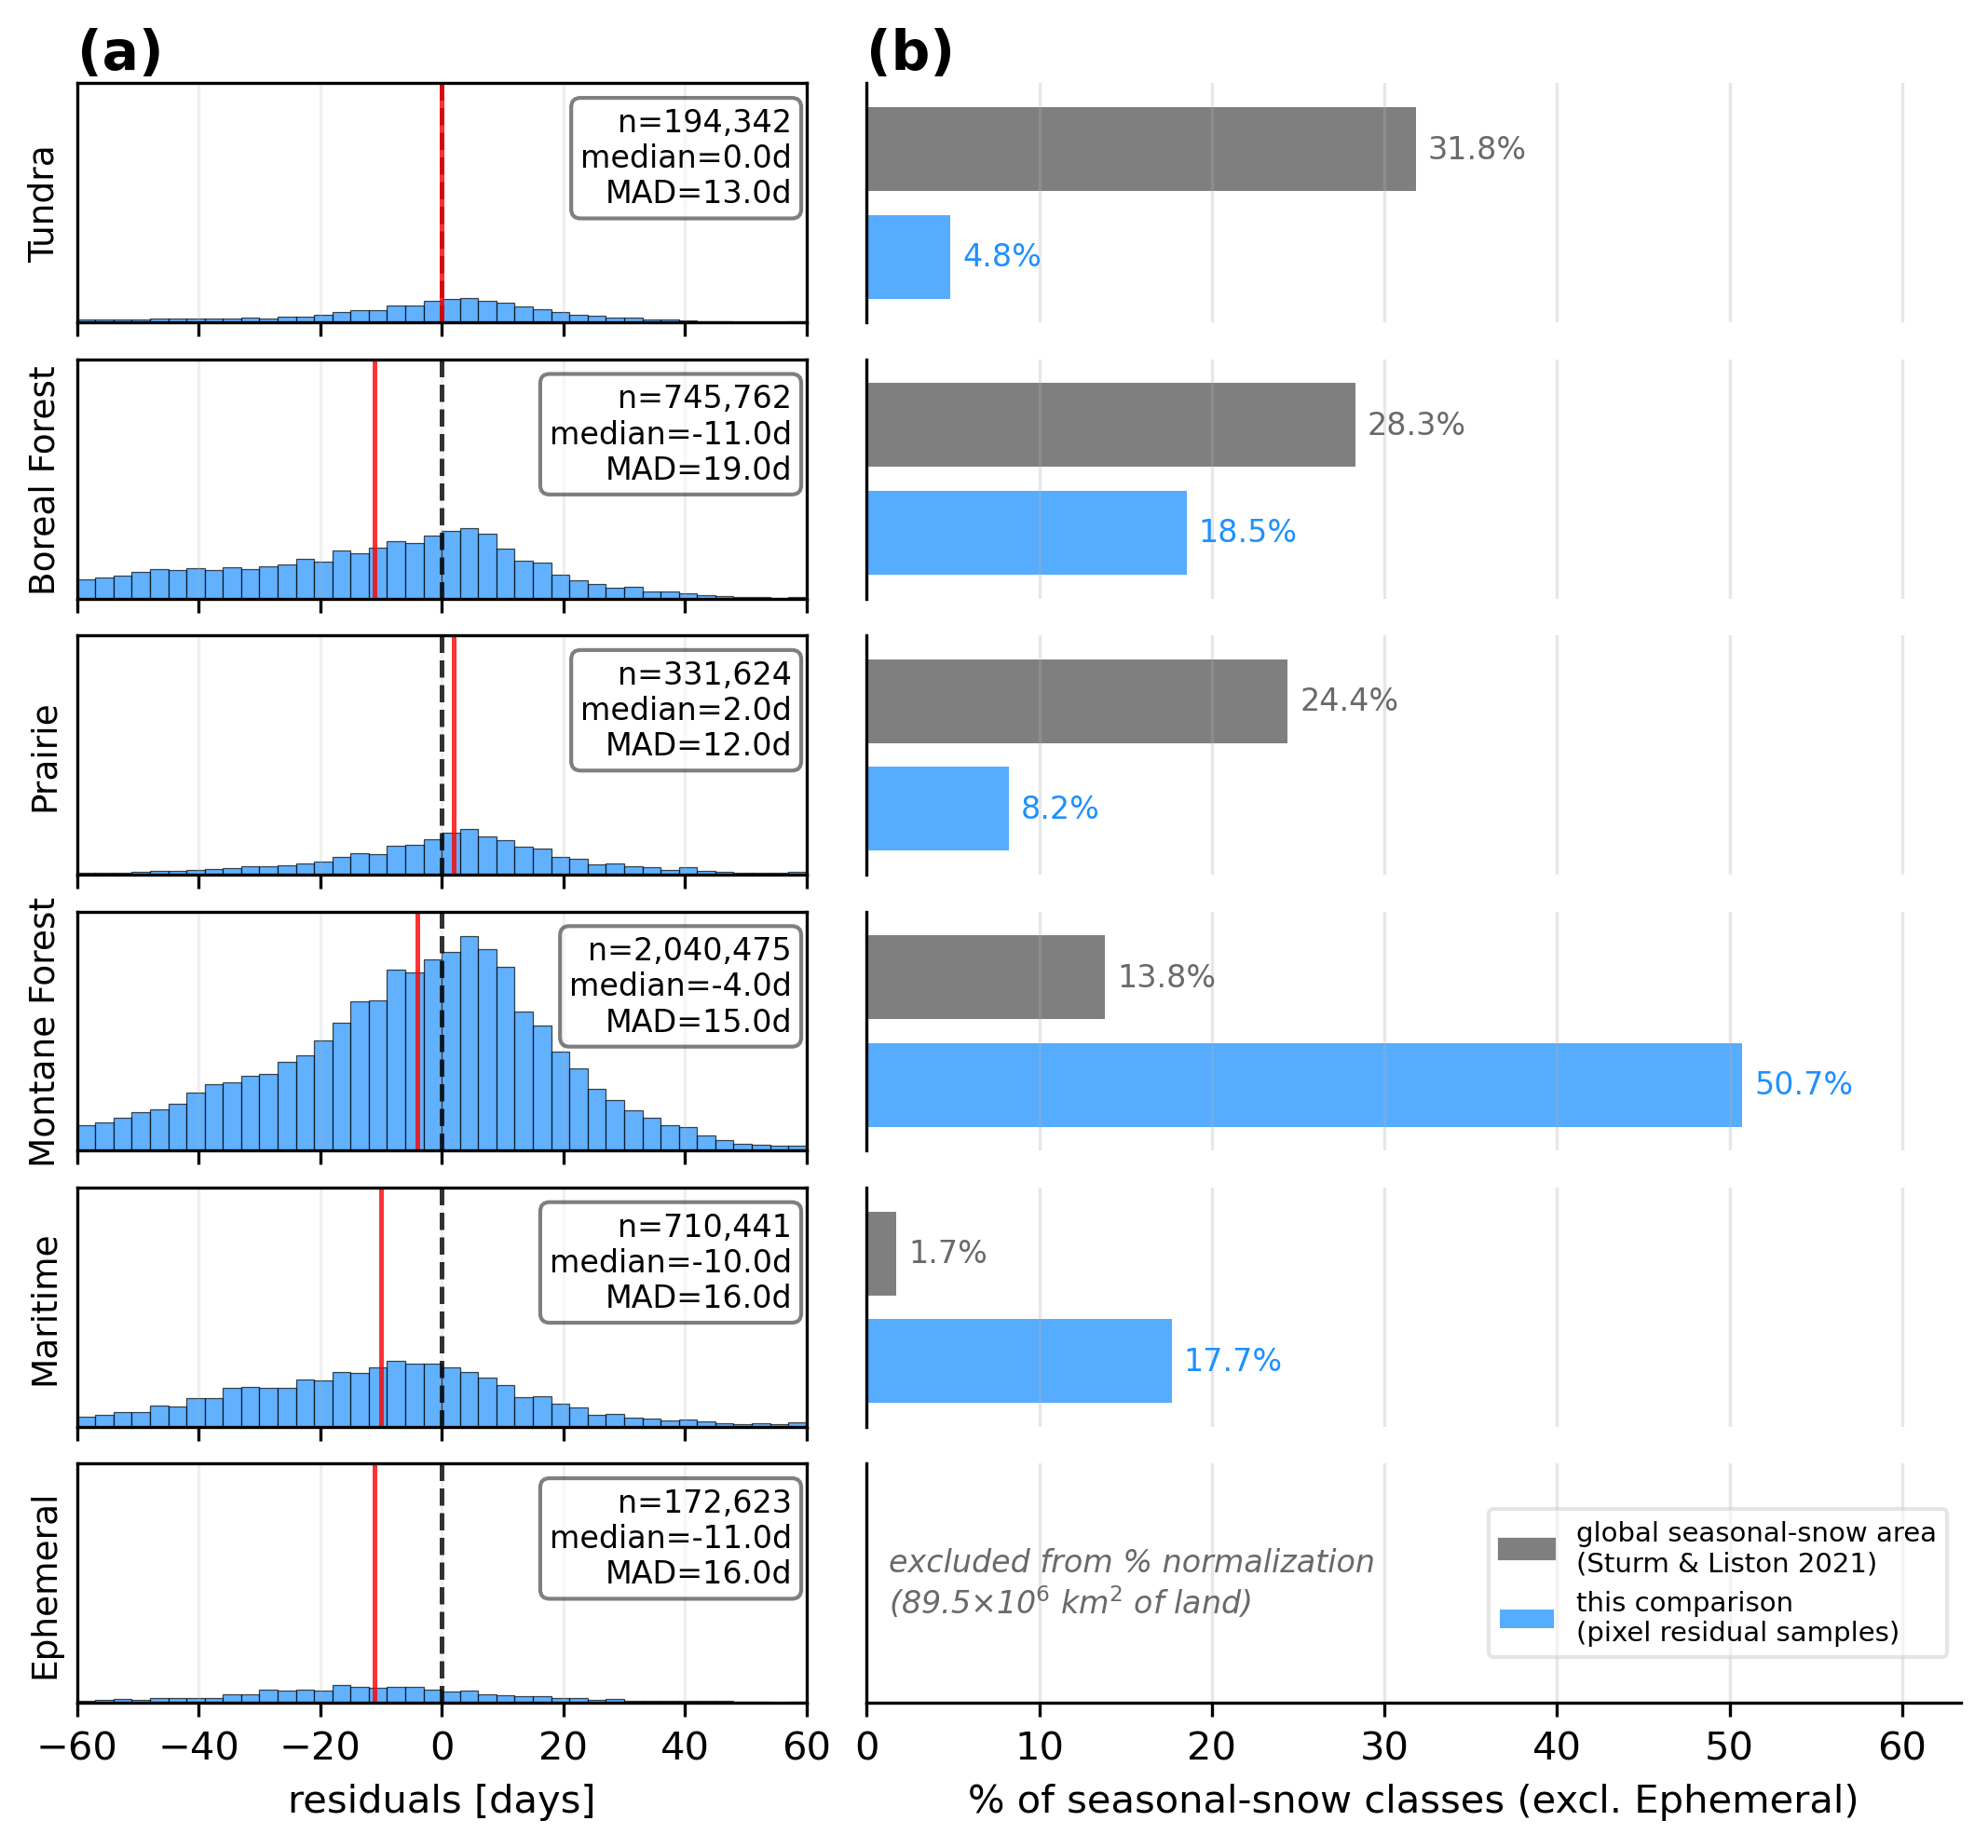

In [25]:
# per-snow-class residual histograms (performance, left) alongside the global
# land-area distribution of the Sturm & Liston (2021) snow classes (prevalence,
# right; their Table 1). Ephemeral is shown for performance but excluded from the
# % normalisation, matching the table's convention.


STURM_LISTON_AREA_MKM2 = {          # 10^6 km^2, Sturm & Liston (2021), Table 1
    "Tundra": 13.7, "Boreal Forest": 12.2, "Montane Forest": 6.0,
    "Prairie": 10.5, "Maritime": 0.7,
    "Ice": 14.6, "Ephemeral": 89.5,  # excluded from the table's % normalisation
}
STURM_LISTON_PCT = {"Tundra": 31.8, "Boreal Forest": 28.3, "Montane Forest": 13.8,
                    "Prairie": 24.4, "Maritime": 1.7}
SEASONAL_CLASSES = list(STURM_LISTON_PCT)   # the five classes the table normalises over

code_by_name = {v: k for k, v in SNOW_CLASS_NAMES.items()}
ok = master_df["err"].notna()

counts = {c: int(((master_df["snow_class"] == code_by_name[c]) & ok).sum())
          for c in SEASONAL_CLASSES}
sample_pct = {c: 100 * counts[c] / sum(counts.values()) for c in SEASONAL_CLASSES}

n_other = int(ok.sum()) - sum(counts.values())
print(f"{n_other:,} of {int(ok.sum()):,} residual samples ({100*n_other/int(ok.sum()):.1f}%) fall in "
      f"Ephemeral/Ice/other classes and are excluded from the % comparison (as in Table 1)")

# rows: seasonal classes sorted by global prevalence, then Ephemeral
# (shown for performance, but excluded from the Table 1 % normalisation)
ROWS = sorted(SEASONAL_CLASSES, key=lambda c: STURM_LISTON_PCT[c], reverse=True) + ["Ephemeral"]
n_rows = len(ROWS)

fig = plt.figure(figsize=(7, 6.5), layout="constrained", dpi=300)
gs = fig.add_gridspec(n_rows, 2, width_ratios=[1, 1.5])

bins = np.linspace(-60, 60, 41)
x_pct_max = max(max(sample_pct.values()), max(STURM_LISTON_PCT.values())) * 1.25

# One subplot per class row on each side (gs[i, 0] left / gs[i, 1] right): because
# the left histogram and the right bars share the same gridspec band, their rows
# stay perfectly aligned (a single spanning axis on the right drifts vs. the
# per-row hist axes because constrained_layout pads each hist cell separately).
hist_axes, bar_axes = [], []
for i, c in enumerate(ROWS):
    # --- left: residual histogram per class (performance) ---
    ax = fig.add_subplot(gs[i, 0], sharex=hist_axes[0] if hist_axes else None)
    hist_axes.append(ax)
    vals = master_df.loc[(master_df["snow_class"] == code_by_name[c]) & ok, "err"].dropna()
    med = vals.median()
    mad = (vals - med).abs().median()

    ax.hist(vals, bins=bins, color="dodgerblue", alpha=0.7, edgecolor="black", linewidth=0.3)
    ax.axvline(0, color="black", ls="--", lw=1.2, alpha=0.8)
    ax.axvline(med, color="red", lw=1.2, alpha=0.8)
    ax.text(0.98, 0.9, f"n={len(vals):,}\nmedian={med:.1f}d\nMAD={mad:.1f}d",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.5, edgecolor="black"))
    ax.set_ylabel(c, rotation=90, ha="center", va="bottom", fontsize=9)
    ax.set_yticks([])
    ax.set_xlim(-60, 60)
    ax.set_ylim([0, 140000])
    ax.grid(alpha=0.2)
    if i < n_rows - 1:
        ax.tick_params(labelbottom=False)

    # --- right: global area share vs our sample share (prevalence) ---
    axr = fig.add_subplot(gs[i, 1], sharex=bar_axes[0] if bar_axes else None)
    bar_axes.append(axr)
    axr.set_yticks([])
    axr.set_ylim(-1, 1)
    axr.grid(alpha=0.3, axis="x")
    
    
    if i < n_rows - 1:
        #axr.tick_params(labelbottom=False)
        axr.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        axr.spines[['top', 'right', 'bottom']].set_visible(False)

        

    #axr.set_xticks([])
        
    axr.spines[['top', 'right', 'bottom']].set_visible(False)

    if c in STURM_LISTON_PCT:
        axr.barh(0.45, STURM_LISTON_PCT[c], height=0.7, color="tab:gray")
        axr.barh(-0.45, sample_pct[c], height=0.7, color="dodgerblue", alpha=0.75)
        axr.text(STURM_LISTON_PCT[c] + 0.7, 0.45, f"{STURM_LISTON_PCT[c]:.1f}%",
                 va="center", fontsize=8, color="dimgray")
        axr.text(sample_pct[c] + 0.7, -0.45, f"{sample_pct[c]:.1f}%",
                 va="center", fontsize=8, color="dodgerblue")
        # dashed guide tying this class's histogram (left) to its bars (right)
        # con = ConnectionPatch(xyA=(1.0, 0.5), coordsA=ax.transAxes,
        #                       xyB=(0.0, 0.5), coordsB=axr.transAxes,
        #                       color="gray", lw=0.8, ls="--", alpha=0.6, zorder=0)
        # fig.add_artist(con)
    else:   # Ephemeral: excluded from the % normalization
        axr.text(0.02, 0.5, "excluded from % normalization\n"
                 f"({STURM_LISTON_AREA_MKM2[c]:.1f}$\\times$10$^6$ km$^2$ of land)",
                 transform=axr.transAxes, va="center", ha="left",
                 fontsize=8, color="dimgray", style="italic")

bar_axes[0].set_xlim(0, x_pct_max)   # shared x across all bar rows
hist_axes[-1].set_xlabel("residuals [days]")
bar_axes[-1].set_xlabel("% of seasonal-snow classes (excl. Ephemeral)")

# legend in the (mostly empty) Ephemeral row, to the right of its note
handles = [Patch(color="tab:gray", label="global seasonal-snow area\n(Sturm & Liston 2021)"),
           Patch(facecolor="dodgerblue", alpha=0.75, label="this comparison\n(pixel residual samples)")]
bar_axes[-1].legend(handles=handles, fontsize=7, loc="center right", framealpha=0.5)

bar_axes[-1].spines['bottom'].set_visible(True)

# f.suptitle("Per-snow-class residuals vs. global snow-class prevalence (Sturm & Liston 2021)",
#            fontweight="bold");

# label as panel a and b, for the paper figure. Both top subplots share the same
# gridspec band, so equal transAxes y => equal figure height => aligned labels.
hist_axes[0].text(0, 1.06, "(a)", transform=hist_axes[0].transAxes, fontsize=14, fontweight="bold")
bar_axes[0].text(0, 1.06, "(b)", transform=bar_axes[0].transAxes, fontsize=14, fontweight="bold")

fig.savefig("figures/performance_vs_prevalence_by_snow_class.png", dpi=300, bbox_inches="tight")

In [26]:
# --- 4. shallow decision tree: find threshold COMBINATIONS --------------------

feat_cont = ["fcf", "temp_res", "max_swe", "radius"]
feat_cat  = ["worldcover", "network"]

X_all = pd.get_dummies(master_df[feat_cont + feat_cat], columns=feat_cat)
ok = master_df["abs_err"].notna() & X_all.notna().all(axis=1)

rng = np.random.RandomState(0)
idx = rng.choice(np.flatnonzero(ok.to_numpy()),
                 size=min(2_000_000, int(ok.sum())), replace=False)
X_tr = X_all.iloc[idx]
y_tr = master_df["abs_err"].iloc[idx]

tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=5_000, random_state=0)
tree.fit(X_tr, y_tr)

# leaves read like: "temp_res <= 6 & fcf <= 25 -> mean |err| = 4.1 d"
print(export_text(tree, feature_names=list(X_tr.columns), decimals=1))

|--- fcf <= 68.5
|   |--- max_swe <= 374.9
|   |   |--- max_swe <= 173.4
|   |   |   |--- fcf <= 8.5
|   |   |   |   |--- value: [24.6]
|   |   |   |--- fcf >  8.5
|   |   |   |   |--- value: [31.3]
|   |   |--- max_swe >  173.4
|   |   |   |--- temp_res <= 10.9
|   |   |   |   |--- value: [20.2]
|   |   |   |--- temp_res >  10.9
|   |   |   |   |--- value: [24.5]
|   |--- max_swe >  374.9
|   |   |--- worldcover_80.0 <= 0.5
|   |   |   |--- fcf <= 47.5
|   |   |   |   |--- value: [15.1]
|   |   |   |--- fcf >  47.5
|   |   |   |   |--- value: [18.8]
|   |   |--- worldcover_80.0 >  0.5
|   |   |   |--- fcf <= 4.5
|   |   |   |   |--- value: [34.7]
|   |   |   |--- fcf >  4.5
|   |   |   |   |--- value: [23.9]
|--- fcf >  68.5
|   |--- fcf <= 92.5
|   |   |--- max_swe <= 423.0
|   |   |   |--- fcf <= 83.5
|   |   |   |   |--- value: [26.1]
|   |   |   |--- fcf >  83.5
|   |   |   |   |--- value: [29.4]
|   |   |--- max_swe >  423.0
|   |   |   |--- temp_res <= 7.2
|   |   |   |   |--- v

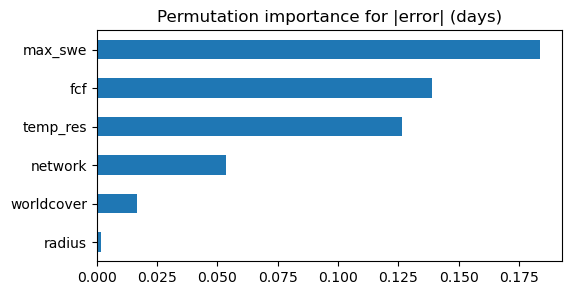

In [27]:
# --- 5. gradient boosting: importance + partial dependence ---------

Xg = master_df[feat_cont].copy()
for c in feat_cat:   # ordinal codes; map NaN (-1) to its own category
    codes = master_df[c].cat.codes.to_numpy()
    Xg[c] = np.where(codes < 0, codes.max() + 1, codes).astype("int16")

n_tr = int(0.85 * len(idx))
idx_tr = idx[:n_tr]
idx_te = idx[n_tr:]
gbm = HistGradientBoostingRegressor(max_iter=300, categorical_features=feat_cat,
                                    random_state=0)
gbm.fit(Xg.iloc[idx_tr], master_df["abs_err"].iloc[idx_tr])

pi = permutation_importance(gbm, Xg.iloc[idx_te], master_df["abs_err"].iloc[idx_te],
                            n_repeats=3, random_state=0, n_jobs=-1)
pd.Series(pi.importances_mean, index=Xg.columns).sort_values().plot.barh(
    title="Permutation importance for |error| (days)", figsize=(6, 3));

### Robustness check: station-year level

Pixels within a chip (and years within a station) are strongly correlated, so the pixel-level `n` wildly overstates the effective sample size. Re-running the sweeps on **one value per station-year** checks that the conclusions aren't an artifact of a handful of stations.

8,982 station-years


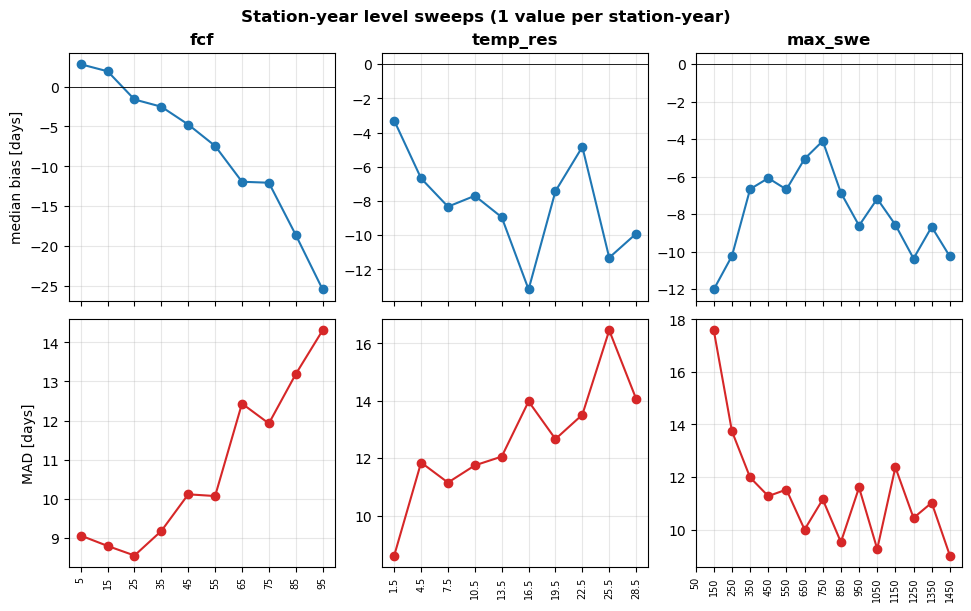

In [28]:
# --- 6. aggregate to station-year, re-run the sweeps --------------------------
sy_df = (master_df
         .groupby(["station_idx", "water_year"], observed=True)
         .agg(err=("err", "mean"),
              fcf=("fcf", "mean"),
              temp_res=("temp_res", "mean"),
              max_swe=("max_swe", "first"),
              n_px=("err", "size"))
         .dropna(subset=["err"])
         .reset_index())
print(f"{len(sy_df):,} station-years")

sy_sweeps = {col: (sy_df.groupby(pd.cut(sy_df[col], bins), observed=False)["err"]
                        .apply(perf_stats).unstack())
             for col, bins in binnings.items() if col != "radius"}

f, axs = plt.subplots(2, len(sy_sweeps), figsize=(3.2 * len(sy_sweeps), 6),
                      layout="constrained")
for j, (name, tbl) in enumerate(sy_sweeps.items()):
    x = np.arange(len(tbl))
    labels = [f"{iv.mid:g}" for iv in tbl.index]
    axs[0, j].plot(x, tbl["bias_median"], "o-"); axs[0, j].axhline(0, color="k", lw=0.6)
    axs[1, j].plot(x, tbl["mad"], "o-", color="tab:red")
    axs[0, j].set_title(name, fontweight="bold")
    for i in range(2):
        axs[i, j].set_xticks(x)
        axs[i, j].set_xticklabels(labels if i == 1 else [], rotation=90, fontsize=7)
        axs[i, j].grid(alpha=0.3)
axs[0, 0].set_ylabel("median bias [days]"); axs[1, 0].set_ylabel("MAD [days]")
f.suptitle("Station-year level sweeps (1 value per station-year)", fontweight="bold");

In [29]:
# --- 7. report card for a candidate "best regime" -----------------------------
# Plug in the thresholds the tree / heatmaps nominate, then verify on BOTH
# pixel level and station-year level. Edit the query string as you iterate.
REGIME = "temp_res <= 6 and fcf <= 30"

pix = master_df.query(REGIME)
sy  = sy_df.query(REGIME)

report = pd.DataFrame({
    "all pixels":        perf_stats(master_df["err"]),
    f"pixels [{REGIME}]": perf_stats(pix["err"]),
    "all station-years": perf_stats(sy_df["err"]),
    f"stn-yrs [{REGIME}]": perf_stats(sy["err"]),
}).T
report["n"] = report["n"].astype(int)
report.round(2)

,bias_median,mad,pct_within_7d,pct_within_10d,pct_within_14d,n
all pixels,-5.00,16.00,27.26,37.02,47.68,4196221
pixels [temp_res <= 6 and fcf <= 30],2.00,11.00,36.87,48.22,60.50,518181
all station-years,-7.45,11.82,30.69,41.91,54.41,8982
stn-yrs [temp_res <= 6 and fcf <= 30],0.71,7.99,45.71,59.83,73.22,687


In [30]:
REGIME = "temp_res <= 14 and fcf <= 50 and max_swe >= 200"

pix = master_df.query(REGIME)
sy  = sy_df.query(REGIME)

report = pd.DataFrame({
    "all pixels":        perf_stats(master_df["err"]),
    f"pixels [{REGIME}]": perf_stats(pix["err"]),
    "all station-years": perf_stats(sy_df["err"]),
    f"stn-yrs [{REGIME}]": perf_stats(sy["err"]),
}).T
report["n"] = report["n"].astype(int)
report.round(2)

,bias_median,mad,pct_within_7d,pct_within_10d,pct_within_14d,n
all pixels,-5.00,16.00,27.26,37.02,47.68,4196221
pixels [temp_res <= 14 and fcf <= 50 and max_swe >= 200],0.00,12.00,34.16,45.62,57.92,1609380
all station-years,-7.45,11.82,30.69,41.91,54.41,8982
stn-yrs [temp_res <= 14 and fcf <= 50 and max_swe >= 200],-1.32,8.92,40.80,54.43,69.10,3230


In [31]:
REGIME = "temp_res <= 14 and fcf <= 50 and max_swe >= 200 and radius <= 500"

pix = master_df.query(REGIME)

report = pd.DataFrame({
    "all pixels":        perf_stats(master_df["err"]),
    f"pixels [{REGIME}]": perf_stats(pix["err"]),
}).T
report["n"] = report["n"].astype(int)
report.round(2)

,bias_median,mad,pct_within_7d,pct_within_10d,pct_within_14d,n
all pixels,-5.0,16.0,27.26,37.02,47.68,4196221
pixels [temp_res <= 14 and fcf <= 50 and max_swe >= 200 and radius <= 500],1.0,11.0,34.74,46.57,58.95,389511
